# Classify Defects on Wafer Maps Using Deep Learning

Wafers are thin disks of semiconducting material, typically silicon, that serve as the foundation for integrated circuits. Each wafer yields several individual circuits (ICs), separated into dies. Automated inspection machines test the performance of ICs on the wafer. The machines produce images, called wafer maps, that indicate which dies perform correctly (pass) and which dies do not meet performance standards (fail).

Load the libraries needed for the project

In [2]:
# First lets load all the libraries we are going to use
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, Input
import numpy as np
import seaborn as sns
import cv2
import gc

Load the data inside a pandas data frame

In [9]:
df=pd.read_pickle("MIR-WM811K\\MIR-WM811K\\Python\\WM811K.pkl")

### Check the data Structure

In [10]:
df.info(memory_usage = "deep")

<class 'pandas.DataFrame'>
RangeIndex: 811457 entries, 0 to 811456
Data columns (total 6 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   dieSize         811457 non-null  float64
 1   failureType     811457 non-null  object 
 2   lotName         811457 non-null  object 
 3   trainTestLabel  811457 non-null  object 
 4   waferIndex      811457 non-null  float64
 5   waferMap        811457 non-null  object 
dtypes: float64(2), object(4)
memory usage: 334.3 MB


### Data Description:
- explain the meaning of each attribute (to do)

Display one instance of the data to see what the data actually looks like.
I also added a command to display the waferMap.

dieSize                                                      1683.0
failureType                                                    none
lotName                                                        lot1
trainTestLabel                                             Training
waferIndex                                                      1.0
waferMap          [[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...
Name: 0, dtype: object


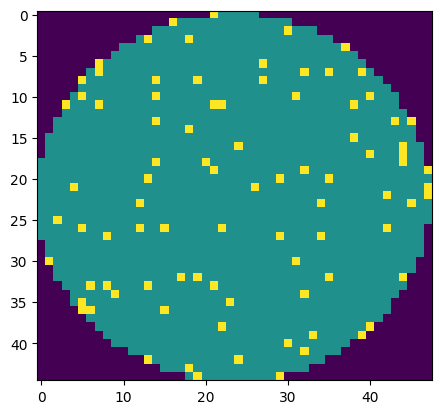

In [11]:
print(df.iloc[0])
plt.imshow(df.iloc[0]['waferMap'],)

### Data Cleaning

Create the training and testing datasets by using the labels of the "trainTestLabel" attribute.

In [12]:
df["trainTestLabel"].explode().value_counts()

trainTestLabel
0           1277014
Test         118595
Training      54355
Name: count, dtype: int64

There are 1277014 unlabelled instances, 118595 testing instances and 54355 training instances. It is preferable to have more training instances than testing instances, so we will create a new data frame with both training and testing labels shuffled and relabelled to obtain 90% training samples and 10% testing samples. 

New dataset generation.

In [13]:
index = []

for element in df["trainTestLabel"]:
    # we make sure the element is a string before checking whether the label is either Test or Training.
    # If that is not the case we proceed to append a False boolean to our index.
    if type(element) == type("string"):
        index.append(True)
    else:
        index.append(False)

In [14]:
NewDataset = df.iloc[index]
print(NewDataset["trainTestLabel"].explode().value_counts())

trainTestLabel
Test        118595
Training     54355
Name: count, dtype: int64


In [15]:
from sklearn.model_selection import train_test_split

# Dividiamo il DataFrame originale in due tabelle (90% training, 10% test)
# Usiamo df_pulito['failureType'] per dire al codice COME stratificare le righe
TrainDataFrame, TestDataFrame = train_test_split(
    NewDataset,
    test_size=0.10, 
    random_state=42,  #per la riproducibilita
    stratify=NewDataset['failureType']
)

IMPORTANT NOTE: We use the .copy() method to create a copy of the filtered data, if we don't do this both dataframes will keep ponting at the data of the original dataset.

In [16]:
TrainDataFrame = TrainDataFrame[["waferMap","failureType"]].copy()
TestDataFrame = TestDataFrame[["waferMap","failureType"]].copy()

A quick check to ensure everything went accordingly

In [17]:
print(df["trainTestLabel"].explode().value_counts())
print(f"\nThe training set has {TrainDataFrame.shape} instances.")
print(f"The test set has {TestDataFrame.shape} instances.")

trainTestLabel
0           1277014
Test         118595
Training      54355
Name: count, dtype: int64

The training set has (155655, 2) instances.
The test set has (17295, 2) instances.


Before we continue we will delete from memory the original data frame df to free up +300MB of memory, which is additional memory the machine will be able to use during training and testing.

In [18]:
def free_memory(filename):
    # 1. Delete the variables for the original dataset 
    # (Replace 'original_dataset' and 'copied_dataset' with your actual variable names)
    del filename

    # If you still have the intermediate copy variable lingering around, delete it too:
    # del copied_dataset 

    # 2. Force Python's Garbage Collector to run immediately and reclaim the RAM
    gc.collect()

    print("Original dataset deleted. +300MB of memory has been freed!")

In [19]:
free_memory(df)

Original dataset deleted. +300MB of memory has been freed!


### Data Exploration

The main porpouse of the research is to create a Deeep Neural Network that can properly classify wafers, so we will start by looking at the different classes of "failureType".

First we will plot the wafer maps for each failure type to actually visualize the different failure types

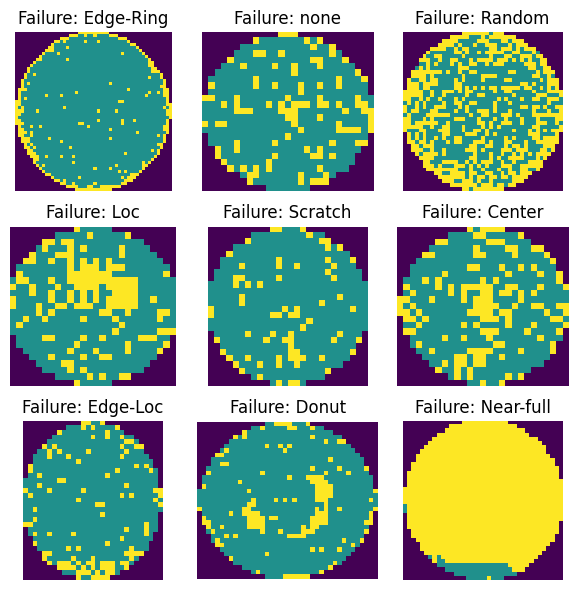

In [20]:
# Get the unique failure types from your dataframe
unique_failures = TrainDataFrame["failureType"].unique()

# Set up a 3x3 grid of subplots
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(6, 6))

# Flatten the axes array to make iterating over it easier
axes = axes.ravel()

for i, failure in enumerate(unique_failures):
    # Filter the dataframe for the current failure type and grab the first row
    sample_row = TrainDataFrame[TrainDataFrame["failureType"] == failure].iloc[0]
    
    # Plot the wafermap using imshow
    axes[i].imshow(sample_row["waferMap"], cmap='viridis')
    axes[i].set_title(f"Failure: {failure}")
    axes[i].axis('off') # Turns off the x and y axes ticks for a cleaner look

# Adjust layout so the titles don't overlap
plt.tight_layout()
plt.show()

Now we will look at the absolute and relative frequencies of each class to check if there are any class imbalances

In [21]:
eda = pd.DataFrame(TrainDataFrame["failureType"].explode().value_counts())
eda["prop (%)"] = round(eda["count"] / sum(eda["count"]), 4) * 100
print(eda)

              count  prop (%)
failureType                  
none         132688     85.24
Edge-Ring      8712      5.60
Edge-Loc       4670      3.00
Center         3865      2.48
Loc            3234      2.08
Scratch        1074      0.69
Random          779      0.50
Donut           499      0.32
Near-full       134      0.09


There are 9 failure types with "none" indicating the wafers that have no defects.
The classes are highly imbalanced because 85.24% of the instances show no defects while half of the other classe, namely "Donut", "Random", "Scratch" and "Near-full" represent less than 2% of the training set.

### Data Preparation for Training

We create the X_train dataset containing only the waferMaps of our samples because we are interested on building a network that can correctly identify the the failure type of a wafer by looking at its map. We create the y_train dataset with the labels of the test data.

In [22]:
X_train = TrainDataFrame["waferMap"].tolist()
y_train = TrainDataFrame["failureType"].tolist()

The last steps before we can finally plug the input data in a neural network are the following:
- image resizing: the wafermaps don't all share the same size, so we must ensure all of them are the shape.
- one-hot encoding: the single values stored in the 2-D array representing the wafermaps cannot be fed into a DNN that works in 3-D inputs. One way to solve this issue is by using one-hot encoding, which basically means creating a binary attribute for each of the three possible pixel values.
- data augmentation: the data is highly imbalanced, the vast majority of our dataset belongs to the none failure type, which means a DNN that can accurately classify the none class can achieve an overall high accuracy on the test dataset regardless of how well it can classify all other classes. 

### One-Hot Encoding the Labels
We are working with a categorical target class so we will encode the labels into 9 different categories.

We are going to perform One-Hot encoding several times so we will create a OneHotEncoding function to make the task easier.

In [23]:
def OneHotEncoding(dataset):
    unique_classes = sorted(list(set(dataset))) 
    # Result: ['Center', 'Donut', 'Edge-Ring', 'Scratch']

    # Create a dictionary mapping: {'Center': 0, 'Donut': 1, ...}
    label_to_int = {classname: idx for idx, classname in enumerate(unique_classes)}
    print("Your Class Mapping:", label_to_int)

    # Perform One-Hot Encoding
    num_classes = 9 # Total classes in your full dataset
    encoded_labels = []

    for label in dataset:
    # Get the integer ID for this string
        label_id = label_to_int[label]
    
        # Create the 9-channel one-hot list
        one_hot = [0] * num_classes
        one_hot[label_id] = 1
    
        encoded_labels.append(one_hot)

    # Let's see what "Donut" looks like now
    print(f"\nString: {dataset[1]} -> One-Hot: {encoded_labels[1]}")
    return encoded_labels

In [24]:
encoded_labels = OneHotEncoding(y_train)

Your Class Mapping: {'Center': 0, 'Donut': 1, 'Edge-Loc': 2, 'Edge-Ring': 3, 'Loc': 4, 'Near-full': 5, 'Random': 6, 'Scratch': 7, 'none': 8}

String: none -> One-Hot: [0, 0, 0, 0, 0, 0, 0, 0, 1]


We will create a dictionary containing the keys from the dictionary used to map the categorical labels into encoded labels, the reason for this is that later we will need to switch our encoded labels back to their original categorical values.

In [25]:
ClassMapping = ["Center","Donut","Edge-Loc","Edge-Ring","Loc","Near-full","Random","Scratch","none"]

### Wafer Standardization (Image Resizing)
The wafermaps' shape varies greatly among the samples, so in order to standardized their size, first we will look at the wafermaps' size distribution.

In [26]:
def sizes(wafers):
    wafershapes = []

    for element in wafers:
        wafershapes.append([len(element), len(element[0])])

    wafershapes = pd.Series(wafershapes)
    shape_freq = wafershapes.value_counts()
    print(shape_freq[:5])

Ww look at the size distribution wuth the data undersampled using as a max cap the number of instances of Edge-Loc, the third most frequent class.

In [27]:
#Let's look at the frequencies of the wafermap sizes in the original dataset
sizes(X_train)

[25, 27]    16912
[26, 26]    12881
[30, 34]    11154
[29, 26]    10590
[27, 25]     9588
Name: count, dtype: int64


If we take a look at the top 5 most frequent image sizes in both of the downsampled datasets we will find that the biggest wafermap (the one with the most pixels) is [39, 37].
Let's see the fraction of samples with a shape smaller or equal than [39, 37]. 

In [28]:
wafershapes = []

for element in X_train:
    wafershapes.append([len(element), len(element[0])])

wafershapes = pd.Series(wafershapes)
shape_freq = wafershapes.value_counts()

counter = 0
for shape in wafershapes:
    if shape[0] <= 39 and shape[1] <= 37:
        counter += 1

print(counter/ sum(shape_freq))

0.6608717998136905


In [29]:
#Lets find the highest and widest wafermaps in the training dataset
max_width = 0
max_height = 0

for index, shape in enumerate(wafershapes):
    if shape[0] > max_height:
        max_height = shape[0]
    if shape[1] > max_width:
        max_width = shape[1]

print(f"The highest map is: {max_height} pixels")
print(f"The widest map is: {max_width} pixels")

The highest map is: 212 pixels
The widest map is: 204 pixels


Around 42% (1 - 0.58) of the wafermaps have a shape smaller or equal to [39, 37], which means that if we standardize the samples in a [39, 37] shape almost half of the samples will lose wafermap data as they are being reduced. We could bring to zero the number of reduced samples by just using a shape with the maximum values for both width and height [212, 204]. The only problem with this approach is that it would increase by more than 30 times ((212/37) x (204/37)) the number of pixels for more than half of the samples, leading to an a significant increase in the memory usage. A better approach is to select a wafershape that is bigger than most of our training wafermaps, but still small enough not to require too much memory to store the augmented wafermaps.

In [30]:
counter = 0
for shape in wafershapes:
    if shape[0] <= 54 and shape[1] <= 54:
        counter += 1

print(counter/ sum(shape_freq))

0.9581060679065883


After a few trials we will select a 54x54 shape because of the following two reasons:
- A 54x54 wafermap is bigger than more than 86% of the samples, which means only less than 14% of the samples will lose information as a result of reduction.
- a square picture can be flipped by keeping its shape unchanged, which helps during data augmentation.

We create a function called standardize_wafermap to perform both padding and image interpolation on the wafermaps.

In [31]:
def standardize_wafermap(wafer_3d, target_shape=(54, 54), pad_vector=[1, 0, 0]):
    """
    Pads and reduces a ONE-HOT ENCODED wafermap (3D array).
    pad_vector defaults to [1, 0, 0] assuming category 0 is the background.
    """
    h, w, channels = wafer_3d.shape
    th, tw = target_shape
    
    # CONDITION 1: Reduce if larger than 38x36
    if h > th or w > tw:
        scale = min(tw / w, th / h)
        new_w = int(w * scale)
        new_h = int(h * scale)
        
        # Resize using INTER_NEAREST to keep strict 0s and 1s in the channels
        processed_wafer = cv2.resize(wafer_3d, (new_w, new_h), interpolation=cv2.INTER_NEAREST)
        
    # CONDITION 2: Keep size if smaller/equal
    else:
        processed_wafer = wafer_3d
        new_h, new_w, _ = processed_wafer.shape
        
    # --- PADDING STEP ---
    
    # 1. Create a 38x36x3 canvas. 
    # We initialize with zeros, then broadcast the pad_vector to every pixel.
    canvas = np.zeros((th, tw, channels), dtype=wafer_3d.dtype)
    canvas[:] = pad_vector 
    
    # 2. Calculate centering offsets
    y_offset = (th - new_h) // 2
    x_offset = (tw - new_w) // 2
    
    # 3. Paste the processed 3D wafer onto the canvas
    canvas[y_offset:y_offset+new_h, x_offset:x_offset+new_w] = processed_wafer
    
    return canvas

We define the FullWaferStandardization function to perform shape standardization and one-hot encoding of the wafermaps.

One-Hot Encoding transforms the single 2D channel into 3 separate channels (one for each category: 0, 1, and 2).
- Channel 0 will have a 1 where the pixel was 0, and 0 everywhere else. It defines whether that location in the wafermap is the background.
- Channel 1 will have a 1 where the pixel was 1, and 0 everywhere else. It tells if the die in that location is working.
- Channel 2 will have a 1 where the pixel was 2, and 0 everywhere else. It tells if the die in that location is not working.

This successfully builds a 3D array: (Height, Width, 3).


In [32]:
def FullWaferStandardization(wafers):
# Assuming 'raw_wafermaps' is a list of your 2D arrays with varying sizes
    processed_wafers = []   
    target_size = (54, 54)

    for raw_wafer in wafers:
    
    # STEP 1: One-Hot Encode First
    # This turns a (H, W) array of 0s, 1s, 2s into a (H, W, 3) array of 0s and 1s.
    # (We use np.eye to do this fast without external deep learning libraries)
        one_hot_wafer = np.eye(3, dtype=np.float32)[raw_wafer] 
    
    # STEP 2: Standardize the 3D array
        standardized_wafer = standardize_wafermap(
            one_hot_wafer, 
            target_shape=target_size, 
            pad_vector=[1, 0, 0] # Background category vector
        )
    
        processed_wafers.append(standardized_wafer)

# Convert the list to your final training batch
# Shape will be: (num_samples, 54, 54, 3)
    return np.array(processed_wafers)

In [33]:
X_train_final = FullWaferStandardization(X_train)
print(f"Final dataset shape: {X_train_final.shape}")

Final dataset shape: (155655, 54, 54, 3)


Lets take look at standardized and encoded wafermaps:

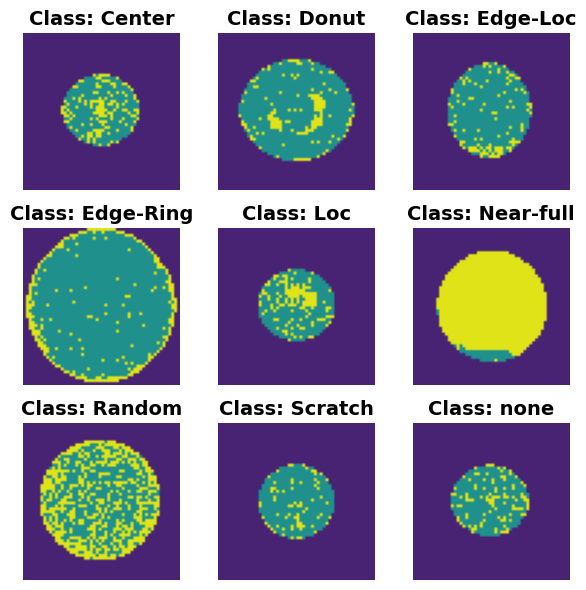

In [34]:
# 1. Prepare labels and find first occurrences
y_train_flat = np.array(y_train).ravel()
unique_classes, indices = np.unique(y_train_flat, return_index=True)

# 2. Set up the 3x3 grid
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(6, 6))
axes = axes.ravel()

# 3. Dynamically extract RGB vectors from the viridis colormap
# We sample at 0.1 (dark purple), 0.5 (green), and 0.95 (bright yellow)
# [:3] discards the alpha (transparency) channel, leaving just [R, G, B]
cmap = plt.get_cmap('viridis')
color_0 = np.array(cmap(0.1)[:3])   # Replaces Channel 0 (e.g., Background)
color_1 = np.array(cmap(0.5)[:3])   # Replaces Channel 1 (e.g., Normal Die)
color_2 = np.array(cmap(0.95)[:3])  # Replaces Channel 2 (e.g., Defect/Failure)

# 4. Loop through and apply the color matrix transformation
for i in range(9):
    idx = indices[i]
    class_label = unique_classes[i]
    
    # Grab the original (54, 54, 3) image and cast to float
    img = X_train_final[idx].astype(float)
    
    # Normalize to [0, 1] if the data is currently 0-255 integer format
    if img.max() > 1.0:
        img /= 255.0
        
    # Remap channels: Blend each channel mask with its assigned viridis color
    custom_img = (
        img[:, :, 0:1] * color_0 + 
        img[:, :, 1:2] * color_1 + 
        img[:, :, 2:3] * color_2
    )
    
    # Clip values to keep them strictly within valid bounds [0.0, 1.0]
    custom_img = np.clip(custom_img, 0, 1)
    
    # Plot the viridis-colored image
    axes[i].imshow(custom_img)
    axes[i].set_title(f"Class: {class_label}", fontsize=14, fontweight='bold')
    axes[i].axis('off')

plt.tight_layout()
plt.show()

### Data augmentation
The data is finally in the format needed to be fed to a DNN. We can now tackle the issue of class imbalance that we encountered earlier.
We are going to create a function that performs the following transformations in order to create more samples:
- flipping the picture horizontally or vertically
- rotate the picture by a multiple of 90°
- add random noise by flipping either channel 1 or channel 2, channel 0 is left untouched because it is the background.

#### The Augmentation Function (Single Wafer)

The Data Augmentation function creates a new syntethic sample from an input sample by taking the original sample and perform a series of operations (the ones mentioned previously).

In [35]:
# Before calling augment_d4, cap 'none' to match largest minority class post-augmentation
none_idx = 8
y_arr = np.array(encoded_labels)
class_indices = np.argmax(y_arr, axis=1)

# Find largest minority class count × 8 (the D4 multiplier)
minority_counts = []
for c in range(9):
    if c != none_idx:
        minority_counts.append(np.sum(class_indices == c))
target_none = max(minority_counts) * 8

# Downsample 'none'
none_mask = np.where(class_indices == none_idx)[0]
keep_none = np.random.RandomState(42).choice(none_mask, size=target_none, replace=False)
other_mask = np.where(class_indices != none_idx)[0]
keep_all = np.sort(np.concatenate([keep_none, other_mask]))

X_trimmed = X_train_final[keep_all]
y_trimmed = y_arr[keep_all]

print(f"'none' reduced: {len(none_mask):,} → {target_none:,}")
print(f"Total before augmentation: {len(X_trimmed):,}")

'none' reduced: 132,688 → 69,696
Total before augmentation: 92,663


In [36]:
def augment_d4(X, y, skip_class_idx=8):
    """
    Applies all 7 non-identity D4 symmetry transforms to every image
    whose class is NOT skip_class_idx (default 8 = 'none').
    
    The 8 elements of D4 (symmetries of a square):
      0. Identity              — (skip, we already have the original)
      1. Rotate 90°            — rot90 k=1
      2. Rotate 180°           — rot90 k=2
      3. Rotate 270°           — rot90 k=3
      4. Flip horizontal       — fliplr
      5. Flip vertical         — flipud
      6. Flip horizontal + 90° — fliplr then rot90
      7. Flip vertical + 90°   — flipud then rot90
    
    Parameters
    ----------
    X : np.ndarray, shape (N, 54, 54, 3)
    y : np.ndarray, shape (N, 9)
    skip_class_idx : int
        Class index to leave un-augmented (the overrepresented class).
    
    Returns
    -------
    X_aug, y_aug : np.ndarray
        Original data + 7 transforms for each non-skip sample.
    """
    transforms = [
        lambda img: np.rot90(img, k=1),
        lambda img: np.rot90(img, k=2),
        lambda img: np.rot90(img, k=3),
        lambda img: np.fliplr(img),
        lambda img: np.flipud(img),
        lambda img: np.rot90(np.fliplr(img), k=1),
        lambda img: np.rot90(np.flipud(img), k=1),
    ]
    
    y_arr = np.array(y)
    class_indices = np.argmax(y_arr, axis=1)
    
    X_aug = list(X)       # start with all originals
    y_aug = list(y_arr)
    
    # Count for progress tracking
    to_augment = np.sum(class_indices != skip_class_idx)
    print(f"Augmenting {to_augment} images × 7 transforms = {to_augment * 7} new samples")
    
    for i in range(len(X)):
        if class_indices[i] == skip_class_idx:
            continue
        
        for t in transforms:
            X_aug.append(t(X[i]))
            y_aug.append(y_arr[i])
    
    X_aug = np.array(X_aug, dtype=np.float32)
    y_aug = np.array(y_aug, dtype=np.float32)   # float32 — avoid the int64 CPU fallback
    
    print(f"Final shape: X={X_aug.shape}, y={y_aug.shape}")
    return X_aug, y_aug

#### Final Pipeline
This final pipeline combines all the functions required for the data augmentation

In [37]:
print("\n--- STEP 1: CALCULATING NEW BALANCING MULTIPLIERS ---")
X_balanced, y_balanced = augment_d4(X_trimmed, y_trimmed, skip_class_idx=8)

print(f"\n🚀 FINAL TRAIN DATA SHAPE: {X_balanced.shape}")
print(f"🚀 FINAL LABELS SHAPE:     {y_balanced.shape}")


--- STEP 1: CALCULATING NEW BALANCING MULTIPLIERS ---
Augmenting 22967 images × 7 transforms = 160769 new samples
Final shape: X=(253432, 54, 54, 3), y=(253432, 9)

🚀 FINAL TRAIN DATA SHAPE: (253432, 54, 54, 3)
🚀 FINAL LABELS SHAPE:     (253432, 9)


Lets perform a quick check to see the distribution of the classes.

In [38]:
# Lets create a numpy aray containing the names of the classes
# ATTENTION: we are using the shrunk_labels dataset to generate the list of the
#            class names because the encoding was performed with that data. If we
#            used the balanced data the names of the classes would be arranged
#            in a different order leading to assigning the wrong name to the 
#            one-hot encoded attribute

class_names = np.array(ClassMapping)

# axis=1 tells NumPy to look across the columns of each row to find the '1'
class_indices = np.argmax(y_balanced, axis=1)

# Map the integer indices back to your actual class string names
# (This requires class_names to be a NumPy array for "fancy indexing")
decoded_labels = class_names[class_indices]

# --- Viewing the Distribution ---
# return_counts=True automatically tallies up the occurrences of each class
unique_classes, counts = np.unique(decoded_labels, return_counts=True)

# Display the results
print("Class Distribution:")
print("-" * 25)
for cls, count in zip(unique_classes, counts):
    print(f"{cls:<10} | {count} samples")

Class Distribution:
-------------------------
Center     | 30920 samples
Donut      | 3992 samples
Edge-Loc   | 37360 samples
Edge-Ring  | 69696 samples
Loc        | 25872 samples
Near-full  | 1072 samples
Random     | 6232 samples
Scratch    | 8592 samples
none       | 69696 samples


In [39]:
np.save('X_balanced_taku.npy', X_balanced)
np.save('y_balanced_taku.npy', y_balanced)

In [ ]:
X_test = TestDataFrame["waferMap"].tolist()
y_test = TestDataFrame["failureType"].tolist()

X_test = FullWaferStandardization(X_test)
print(f"Final dataset shape: {X_test.shape}")

y_test = OneHotEncoding(y_test)

np.save('X_test_taku.npy', X_test.astype(np.float32))
np.save('y_test_taku.npy', np.asarray(y_test, dtype=np.float32))

print(X_test.shape, y_test.shape)

Final dataset shape: (17295, 54, 54, 3)
Your Class Mapping: {'Center': 0, 'Donut': 1, 'Edge-Loc': 2, 'Edge-Ring': 3, 'Loc': 4, 'Near-full': 5, 'Random': 6, 'Scratch': 7, 'none': 8}

String: none -> One-Hot: [0, 0, 0, 0, 0, 0, 0, 0, 1]


### Load Data From Local storage

In [8]:
X_balanced= np.load('X_balanced_taku.npy')
y_balanced= np.load('y_balanced_taku.npy')

X_test = np.load('X_test_taku.npy')
y_test = np.load('y_test_taku.npy')
print(X_test.shape, y_test.shape, X_test.dtype, y_test.dtype)

(17295, 54, 54, 3) (17295, 9) float32 float32


At first we will train the ModelV1 on a downsampled training dataset, with a max cap of 8712 samples, which means we are downsampling the majority class. Using  the full dataset is not feasible because it is too heavy to be loaded on our laptops. We preprocess the training data and labels so they can be in the correct format required by the Neural Network.

### Model Architecture (ModelV1)

Explain the model architecture.

In [33]:
# --- 1. Define Shapes Based on the input Data ---
input_shape = (54, 54, 3)  # 3 channels per pixel
num_classes = 9           # 9 attributes, one-hot encoded

modelv1 = models.Sequential([
    # Input & MATLAB-style normalization (Min=0, Max=2)
    layers.Input(shape=input_shape),
    layers.Rescaling(scale=1.0/2.0), 
    
    # Block 1: 54x54x3 -> 27x27x8 after MaxPool
    layers.Conv2D(8, (3, 3), padding='same'),
    layers.BatchNormalization(),
    layers.ReLU(),
    layers.MaxPooling2D(pool_size=(2, 2)),
    
    # Block 2: 27x27x8 -> 13x13x16 after MaxPool
    layers.Conv2D(16, (3, 3), padding='same'),
    layers.BatchNormalization(),
    layers.ReLU(),
    layers.MaxPooling2D(pool_size=(2, 2)),
    
    # Block 3: 13x13x16 -> 6x6x32 after MaxPool
    layers.Conv2D(32, (3, 3), padding='same'),
    layers.BatchNormalization(),
    layers.ReLU(),
    layers.MaxPooling2D(pool_size=(2, 2)),
    
    # Block 4: Stays 6x6x64
    layers.Conv2D(64, (3, 3), padding='same'),
    layers.BatchNormalization(),
    layers.ReLU(),
    
    layers.Dropout(0.5),
    layers.Flatten(),                  # Flattens 6x6x64 into a 2304-element vector
    layers.Dense(num_classes),         # 9 outputs
    layers.Activation('softmax')
])

In [34]:
modelv1.compile(
    optimizer= keras.optimizers.Adam(learning_rate=0.001, weight_decay=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

### Training on Original dataset

We train ModelV1 on the original training dataset.

We load the testing dataset to look at the model's loss function during training to help visualize whether the network is overfitting or underfitting.

In [ ]:
history = modelv1.fit(
    x=X_balanced,                      # Your 54x54x3 training images
    y=y_balanced,                      # Your one-hot encoded labels
    epochs=40,                      # MaxEpochs=30
    batch_size=64,                 # MiniBatchSize=64
    shuffle=True,                   # Shuffle="every-epoch"
    verbose=1,                      # Shows a live progress bar for each epoch    
    validation_split=0.2                # Handling the Validation Data
)

Epoch 1/40
3168/3168 ━━━━━━━━━━━━━━━━━━━━ 170s 51ms/step - accuracy: 0.8715 - loss: 0.3716 - val_accuracy: 0.8867 - val_loss: 0.2872
Epoch 2/40
3168/3168 ━━━━━━━━━━━━━━━━━━━━ 128s 40ms/step - accuracy: 0.9173 - loss: 0.2334 - val_accuracy: 0.9091 - val_loss: 0.2369
Epoch 3/40
3168/3168 ━━━━━━━━━━━━━━━━━━━━ 124s 39ms/step - accuracy: 0.9287 - loss: 0.2004 - val_accuracy: 0.9272 - val_loss: 0.1916
Epoch 4/40
3168/3168 ━━━━━━━━━━━━━━━━━━━━ 125s 39ms/step - accuracy: 0.9364 - loss: 0.1807 - val_accuracy: 0.9225 - val_loss: 0.2111
Epoch 5/40
3168/3168 ━━━━━━━━━━━━━━━━━━━━ 120s 38ms/step - accuracy: 0.9406 - loss: 0.1681 - val_accuracy: 0.9286 - val_loss: 0.1894
Epoch 6/40
3168/3168 ━━━━━━━━━━━━━━━━━━━━ 120s 38ms/step - accuracy: 0.9433 - loss: 0.1592 - val_accuracy: 0.9291 - val_loss: 0.1917
Epoch 7/40
3168/3168 ━━━━━━━━━━━━━━━━━━━━ 121s 38ms/step - accuracy: 0.9464 - loss: 0.1518 - val_accuracy: 0.9397 - val_loss: 0.1635
Epoch 8/40
3168/3168 ━━━━━━━━━━━━━━━━━━━━ 121s 38ms/step - accuracy: 

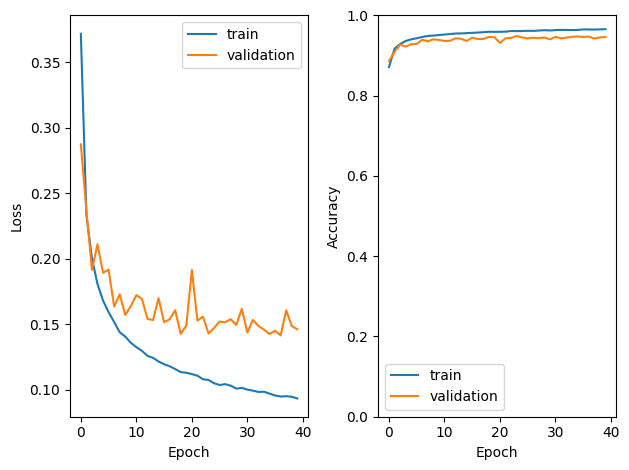

In [36]:
# Visualization of the learning curves
# Loss
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['train', 'validation'])
# Accuracy
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.ylim([0.0, 1.0])
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['train', 'validation'])

plt.tight_layout()

We save the model and the history object on a separate files for later retrieval. This will remove the need of going through the whole preprocessing pipeline and training (which takes on average 30 minutes on our laptops) every single time we start the notebook.

In [37]:
modelv1.save("taku_modelv1.keras")

### Testing
Before testing it is necessary to one-hot encode the test dataset.

### Evaluation ModelV1

Now we can retrieve both the trained model and testing data directly from their files.

In [ ]:
# Test safely using a batch size
test_loss, test_acc = modelv1.evaluate(X_test, y_test, batch_size=128, verbose=1)

print(f"\nFinal Test Accuracy: {test_acc * 100:.2f}%")

(17295, 54, 54, 3) (17295, 9)
136/136 ━━━━━━━━━━━━━━━━━━━━ 8s 59ms/step - accuracy: 0.9777 - loss: 0.0711

Final Test Accuracy: 97.77%


In [42]:
print("Generating predictions... This might take a few minutes.")

# 1. Get raw probabilities for all 118,595 images
# The output will be a massive matrix of shape (118595, 9)
predictions = modelv1.predict(X_test, batch_size=128, verbose=1)

# 2. Convert probabilities into final class choices (0 through 8)
# np.argmax looks at the 9 probabilities for each image and picks the highest one
predicted_classes = np.argmax(predictions, axis=1)

# 3. Convert your one-hot encoded test labels into standard class numbers too
true_classes = np.argmax(y_test, axis=1)

print("\nPredictions generated successfully!")
print(f"First 10 predicted classes: {predicted_classes[:10]}")
print(f"First 10 actual classes:    {true_classes[:10]}")

Generating predictions... This might take a few minutes.
136/136 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step

Predictions generated successfully!
First 10 predicted classes: [8 8 8 8 8 3 8 0 4 8]
First 10 actual classes:    [8 8 8 8 8 3 8 0 4 8]


In [43]:
from sklearn.metrics import confusion_matrix

predicted_classes = np.argmax(predictions, axis=1)

# 1. Generate the confusion matrix
cm = confusion_matrix(true_classes, predicted_classes)

# 2. Calculate per-class accuracy
# cm.diagonal() gets the correctly predicted count for each class
# cm.sum(axis=1) gets the total actual count for each class
class_accuracies = cm.diagonal() / cm.sum(axis=1)

# 3. Print the results clearly
print("Per-Class Accuracy:")
print("-" * 25)
for class_idx, acc in enumerate(class_accuracies):
    # Grab the actual name from your list using the index
    class_name = ClassMapping[class_idx]
    print(f"Class {class_name}: {acc * 100:.2f}%")
    
# Optional: Print the overall average of these class accuracies (Macro Average)
macro_accuracy = np.mean(class_accuracies)
print("-" * 25)
print(f"Average (Macro) Accuracy: {macro_accuracy * 100:.2f}%")

Per-Class Accuracy:
-------------------------
Class Center: 94.64%
Class Donut: 83.93%
Class Edge-Loc: 84.20%
Class Edge-Ring: 98.04%
Class Loc: 78.83%
Class Near-full: 93.33%
Class Random: 91.95%
Class Scratch: 73.11%
Class none: 99.07%
-------------------------
Average (Macro) Accuracy: 88.57%


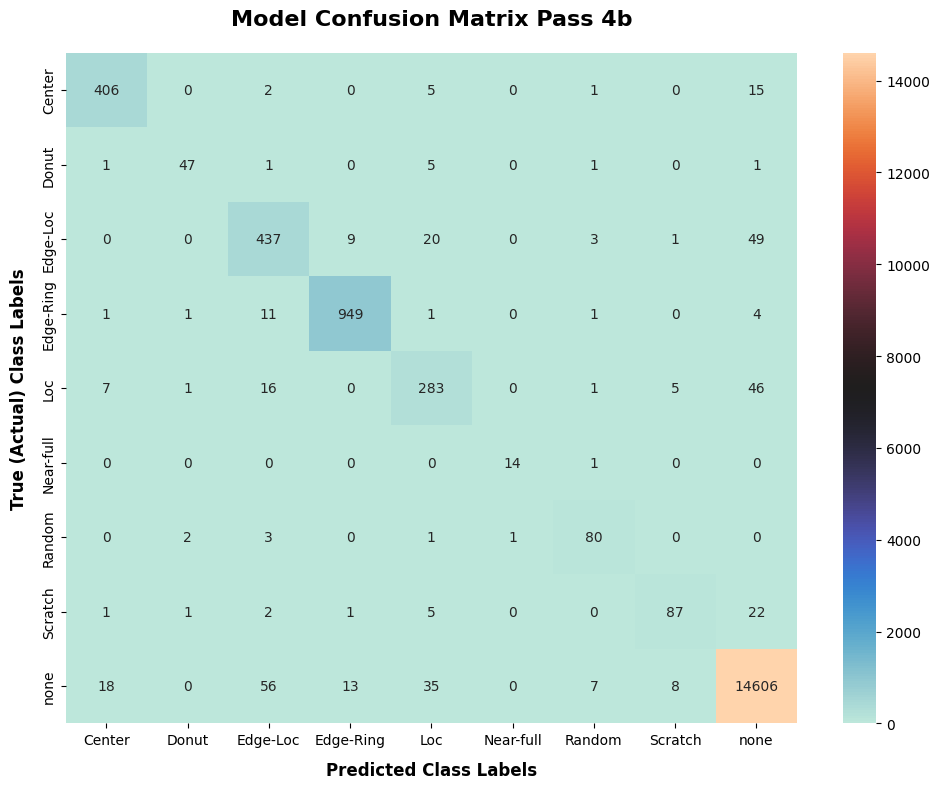

In [44]:
# 1. Calculate the raw confusion matrix numerical values
# (Assumes true_classes and predicted_classes are defined from the predict step)
cm = confusion_matrix(true_classes, predicted_classes)

# 2. Set up the figure size (10x8 inches works well for 9 classes)
plt.figure(figsize=(10, 8))

# 3. Create the colored heatmap
# annot=True plots the numbers inside each square
# fmt='d' forces plain integer format (no scientific notation)
# cmap='Blues' applies a light-to-dark blue gradient based on the numbers
class_names = ClassMapping

sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='icefire', 
    xticklabels=class_names, 
    yticklabels=class_names
)

# 4. Add clear labels and styling
plt.title('Model Confusion Matrix Pass 4b', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Predicted Class Labels', fontsize=12, fontweight='bold', labelpad=10)
plt.ylabel('True (Actual) Class Labels', fontsize=12, fontweight='bold', labelpad=10)

# Adjust layout so labels don't get cut off
plt.tight_layout()

# 5. Render the plot on your screen
plt.show()

### Model Architecture (ModelV1b)
We will reuse the architecture of ModelV1 but on the balanced data, we will call this model ModelV1b.

In [45]:
# --- 1. Define Shapes Based on the input Data ---
input_shape = (54, 54, 3)  # 3 channels per pixel
num_classes = 9           # 9 attributes, one-hot encoded

modelv1b = models.Sequential([
    # Input & MATLAB-style normalization (Min=0, Max=2)
    layers.Input(shape=input_shape),
    layers.Rescaling(scale=1.0/2.0), 
    
    # Block 1: 54x54x3 -> 27x27x8 after MaxPool
    layers.Conv2D(8, (3, 3), padding='same'),
    layers.BatchNormalization(),
    layers.ReLU(),
    layers.MaxPooling2D(pool_size=(2, 2)),
    
    # Block 2: 27x27x8 -> 13x13x16 after MaxPool
    layers.Conv2D(16, (3, 3), padding='same'),
    layers.BatchNormalization(),
    layers.ReLU(),
    layers.MaxPooling2D(pool_size=(2, 2)),
    
    # Block 3: 13x13x16 -> 6x6x32 after MaxPool
    layers.Conv2D(32, (3, 3), padding='same'),
    layers.BatchNormalization(),
    layers.ReLU(),
    layers.MaxPooling2D(pool_size=(2, 2)),
    
    # Block 4: Stays 6x6x64
    layers.Conv2D(64, (3, 3), padding='same'),
    layers.BatchNormalization(),
    layers.ReLU(),
    
    layers.Dropout(0.5),
    layers.Flatten(),                  # Flattens 6x6x64 into a 2304-element vector
    layers.Dense(num_classes),         # 9 outputs
    layers.Activation('softmax')
])

In [46]:
modelv1b.compile(
    optimizer= keras.optimizers.Adam(learning_rate=0.001, weight_decay=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [47]:
# Compute class weights from our augmented data
class_indices = np.argmax(y_balanced, axis=1)
total = len(class_indices)
num_classes = 9

class_weights = {}
for c in range(num_classes):
    count = np.sum(class_indices == c)
    class_weights[c] = total / (num_classes * count)

# Check what the model will see
ClassMapping = ["Center","Donut","Edge-Loc","Edge-Ring","Loc","Near-full","Random","Scratch","none"]
print(f"{'Class':<12} {'Count':>8} {'Weight':>8}")
print("-" * 30)
for c in range(num_classes):
    count = np.sum(class_indices == c)
    print(f"{ClassMapping[c]:<12} {count:>8,} {class_weights[c]:>8.3f}")

Class           Count   Weight
------------------------------
Center         30,920    0.911
Donut           3,992    7.054
Edge-Loc       37,360    0.754
Edge-Ring      69,696    0.404
Loc            25,872    1.088
Near-full       1,072   26.268
Random          6,232    4.518
Scratch         8,592    3.277
none           69,696    0.404


In [48]:
history_v1b = modelv1b.fit(
    x=X_balanced,
    y=y_balanced,
    epochs=40,
    batch_size=64,
    shuffle=True,
    verbose=1,
    validation_split=0.2,
    class_weight=class_weights    # ← this is the only change from Pass 4b
)

Epoch 1/40
3168/3168 ━━━━━━━━━━━━━━━━━━━━ 142s 44ms/step - accuracy: 0.7980 - loss: 0.5929 - val_accuracy: 0.8588 - val_loss: 0.3744
Epoch 2/40
3168/3168 ━━━━━━━━━━━━━━━━━━━━ 123s 39ms/step - accuracy: 0.8768 - loss: 0.3625 - val_accuracy: 0.8151 - val_loss: 0.4698
Epoch 3/40
3168/3168 ━━━━━━━━━━━━━━━━━━━━ 117s 37ms/step - accuracy: 0.8969 - loss: 0.3004 - val_accuracy: 0.9058 - val_loss: 0.2475
Epoch 4/40
3168/3168 ━━━━━━━━━━━━━━━━━━━━ 119s 38ms/step - accuracy: 0.9079 - loss: 0.2654 - val_accuracy: 0.9004 - val_loss: 0.2623
Epoch 5/40
3168/3168 ━━━━━━━━━━━━━━━━━━━━ 120s 38ms/step - accuracy: 0.9149 - loss: 0.2408 - val_accuracy: 0.9134 - val_loss: 0.2322
Epoch 6/40
3168/3168 ━━━━━━━━━━━━━━━━━━━━ 119s 38ms/step - accuracy: 0.9208 - loss: 0.2233 - val_accuracy: 0.8884 - val_loss: 0.3037
Epoch 7/40
3168/3168 ━━━━━━━━━━━━━━━━━━━━ 117s 37ms/step - accuracy: 0.9237 - loss: 0.2136 - val_accuracy: 0.9146 - val_loss: 0.2319
Epoch 8/40
3168/3168 ━━━━━━━━━━━━━━━━━━━━ 117s 37ms/step - accuracy: 

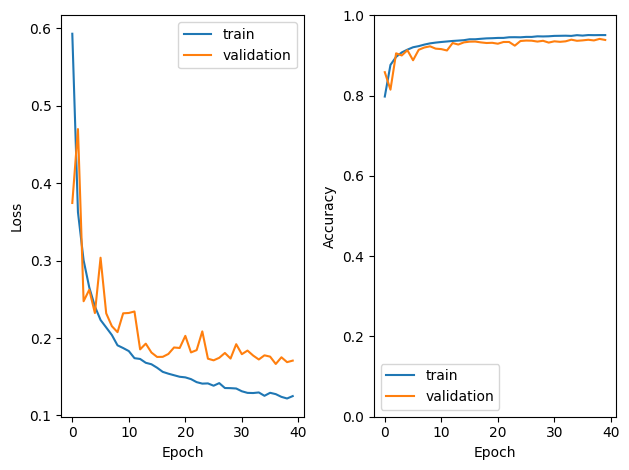

In [49]:
# Visualization of the learning curves
# Loss
plt.subplot(1, 2, 1)
plt.plot(history_v1b.history['loss'])
plt.plot(history_v1b.history['val_loss'])
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['train', 'validation'])
# Accuracy
plt.subplot(1, 2, 2)
plt.plot(history_v1b.history['accuracy'])
plt.plot(history_v1b.history['val_accuracy'])
plt.ylim([0.0, 1.0])
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['train', 'validation'])

plt.tight_layout()

In [50]:
# Save Modelv1b
modelv1b.save("taku_modelv1b.keras")

# Convert the history dictionary to a Pandas DataFrame
history_df = pd.DataFrame(history_v1b.history)

# Save to CSV
history_df.to_csv('history_modelv1b.csv', index=False)

# --- To load it back later ---
loaded_df = pd.read_csv('history_modelv1b.csv')

### Evaluation ModelV1b

In [52]:
X_test = X_test.astype(np.float32) 
y_test = np.array(y_test, dtype=np.float32)

test_loss, test_acc = modelv1b.evaluate(X_test, y_test, batch_size=128, verbose=1)

print(f"\nFinal Test Accuracy: {test_acc * 100:.2f}%")

136/136 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.9666 - loss: 0.1083

Final Test Accuracy: 96.66%


In [53]:
print("Generating predictions... This might take a few minutes.")

# 1. Get raw probabilities for all 118,595 images
# The output will be a massive matrix of shape (118595, 9)
predictions = modelv1b.predict(X_test, batch_size=128, verbose=1)

# 2. Convert probabilities into final class choices (0 through 8)
# np.argmax looks at the 9 probabilities for each image and picks the highest one
predicted_classes = np.argmax(predictions, axis=1)

# 3. Convert your one-hot encoded test labels into standard class numbers too
true_classes = np.argmax(y_test, axis=1)

print("\nPredictions generated successfully!")
print(f"First 10 predicted classes: {predicted_classes[:10]}")
print(f"First 10 actual classes:    {true_classes[:10]}")

Generating predictions... This might take a few minutes.
136/136 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step

Predictions generated successfully!
First 10 predicted classes: [8 8 8 8 8 3 2 0 4 8]
First 10 actual classes:    [8 8 8 8 8 3 8 0 4 8]


In [54]:
from sklearn.metrics import confusion_matrix

ClassMapping = ["Center","Donut","Edge-Loc","Edge-Ring","Loc","Near-full","Random","Scratch","none"]
predicted_classes = np.argmax(predictions, axis=1)

# 1. Generate the confusion matrix
cm = confusion_matrix(true_classes, predicted_classes)

# 2. Calculate per-class accuracy
# cm.diagonal() gets the correctly predicted count for each class
# cm.sum(axis=1) gets the total actual count for each class
class_accuracies = cm.diagonal() / cm.sum(axis=1)

# 3. Print the results clearly
print("Per-Class Accuracy:")
print("-" * 25)
for class_idx, acc in enumerate(class_accuracies):
    # Grab the actual name from your list using the index
    class_name = ClassMapping[class_idx]
    print(f"Class {class_name}: {acc * 100:.2f}%")
    
# Optional: Print the overall average of these class accuracies (Macro Average)
macro_accuracy = np.mean(class_accuracies)
print("-" * 25)
print(f"Average (Macro) Accuracy: {macro_accuracy * 100:.2f}%")

Per-Class Accuracy:
-------------------------
Class Center: 96.04%
Class Donut: 85.71%
Class Edge-Loc: 86.71%
Class Edge-Ring: 97.93%
Class Loc: 76.04%
Class Near-full: 100.00%
Class Random: 97.70%
Class Scratch: 90.76%
Class none: 97.52%
-------------------------
Average (Macro) Accuracy: 92.05%


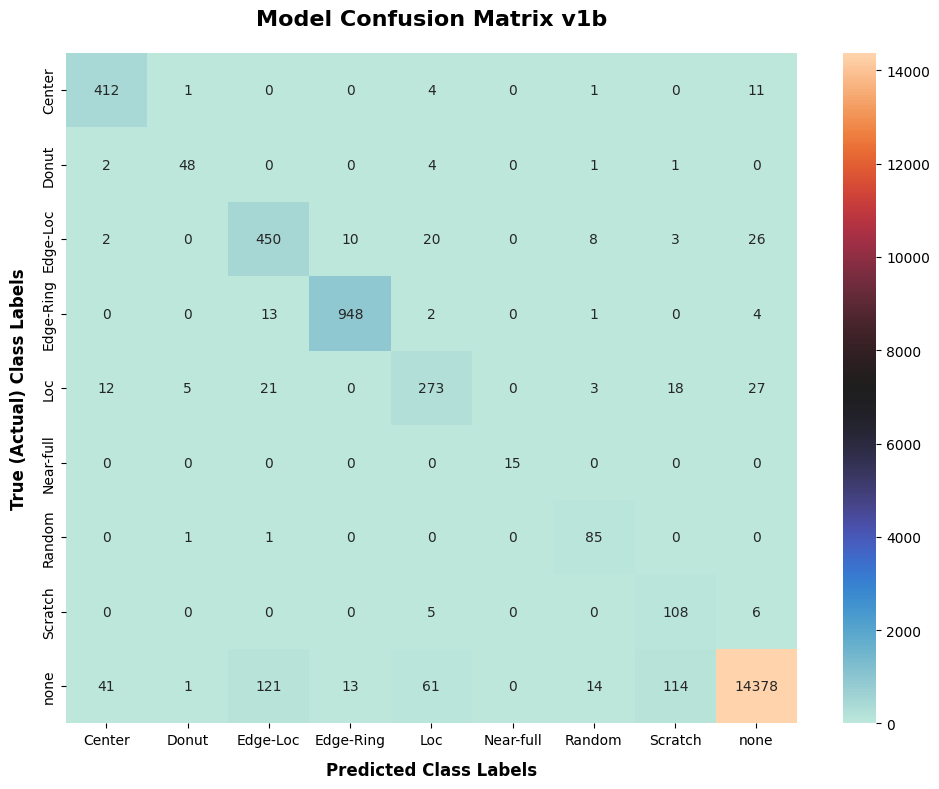

In [55]:
# 1. Calculate the raw confusion matrix numerical values
# (Assumes true_classes and predicted_classes are defined from the predict step)
cm = confusion_matrix(true_classes, predicted_classes)

# 2. Set up the figure size (10x8 inches works well for 9 classes)
plt.figure(figsize=(10, 8))

# 3. Create the colored heatmap
# annot=True plots the numbers inside each square
# fmt='d' forces plain integer format (no scientific notation)
# cmap='Blues' applies a light-to-dark blue gradient based on the numbers
class_names = ClassMapping

sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='icefire', 
    xticklabels=class_names, 
    yticklabels=class_names
)

# 4. Add clear labels and styling
plt.title('Model Confusion Matrix v1b', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Predicted Class Labels', fontsize=12, fontweight='bold', labelpad=10)
plt.ylabel('True (Actual) Class Labels', fontsize=12, fontweight='bold', labelpad=10)

# Adjust layout so labels don't get cut off
plt.tight_layout()

# 5. Render the plot on your screen
plt.show()

### Model Architecture (ModelV2a)
Adding Two channel encoding normalized (x, y). This directly gives the network the positional signal of each defect pattern

In [9]:
# --- 1. Define Shapes Based on the input Data ---
input_shape = (54, 54, 3)  # 3 channels per pixel
num_classes = 9           # 9 attributes, one-hot encoded

# Coordinate channels (CoordConv). 
class AddCoordChannels(layers.Layer):
    """Concatenate normalized x, y (and optional radial r) channels to the input."""
    def __init__(self, with_r=True, **kwargs):
        super().__init__(**kwargs)
        self.with_r = with_r

    def call(self, inputs):
        batch = tf.shape(inputs)[0]
        h, w = inputs.shape[1], inputs.shape[2]          # static (54, 54)
        ones = tf.ones((batch, h, w, 1), dtype=inputs.dtype)
        xx = tf.cast(tf.reshape(tf.linspace(-1.0, 1.0, w), (1, 1, w, 1)), inputs.dtype)
        yy = tf.cast(tf.reshape(tf.linspace(-1.0, 1.0, h), (1, h, 1, 1)), inputs.dtype)
        xx, yy = ones * xx, ones * yy                    # (batch, h, w, 1) each
        out = tf.concat([inputs, xx, yy], axis=-1)
        if self.with_r:
            rr = tf.sqrt(tf.square(xx) + tf.square(yy)) / tf.cast(tf.sqrt(2.0), inputs.dtype)
            out = tf.concat([out, rr], axis=-1)
        return out                                       # 3 channels -> 6

    def get_config(self):
        cfg = super().get_config(); cfg.update({"with_r": self.with_r}); return cfg


modelv2a = models.Sequential([
    # Input & MATLAB-style normalization (Min=0, Max=2)
    layers.Input(shape=input_shape),
    layers.Rescaling(scale=1.0/2.0),
    AddCoordChannels(with_r=True),

    # Block 1: 54x54x3 -> 27x27x8 after MaxPool
    layers.Conv2D(8, (3, 3), padding='same'),
    layers.BatchNormalization(),
    layers.ReLU(),
    layers.MaxPooling2D(pool_size=(2, 2)),
    
    # Block 2: 27x27x8 -> 13x13x16 after MaxPool
    layers.Conv2D(16, (3, 3), padding='same'),
    layers.BatchNormalization(),
    layers.ReLU(),
    layers.MaxPooling2D(pool_size=(2, 2)),
    
    # Block 3: 13x13x16 -> 6x6x32 after MaxPool
    layers.Conv2D(32, (3, 3), padding='same'),
    layers.BatchNormalization(),
    layers.ReLU(),
    layers.MaxPooling2D(pool_size=(2, 2)),
    
    # Block 4: Stays 6x6x64
    layers.Conv2D(64, (3, 3), padding='same'),
    layers.BatchNormalization(),
    layers.ReLU(),
    
    layers.Dropout(0.5),
    layers.Flatten(),                  # Flattens 6x6x64 into a 2304-element vector
    layers.Dense(num_classes),         # 9 outputs
    layers.Activation('softmax')
])

In [10]:
modelv2a.compile(
    optimizer= keras.optimizers.Adam(learning_rate=0.001, weight_decay=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


# Compute class weights from our augmented data
class_indices = np.argmax(y_balanced, axis=1)
total = len(class_indices)
num_classes = 9

class_weights = {}
for c in range(num_classes):
    count = np.sum(class_indices == c)
    class_weights[c] = total / (num_classes * count)

# Check what the model will see
ClassMapping = ["Center","Donut","Edge-Loc","Edge-Ring","Loc","Near-full","Random","Scratch","none"]
print(f"{'Class':<12} {'Count':>8} {'Weight':>8}")
print("-" * 30)
for c in range(num_classes):
    count = np.sum(class_indices == c)
    print(f"{ClassMapping[c]:<12} {count:>8,} {class_weights[c]:>8.3f}")


history_v2a = modelv2a.fit(
    x=X_balanced,
    y=y_balanced,
    epochs=40,
    batch_size=64,
    shuffle=True,
    verbose=1,
    validation_split=0.2,
)

Class           Count   Weight
------------------------------
Center         30,920    0.911
Donut           3,992    7.054
Edge-Loc       37,360    0.754
Edge-Ring      69,696    0.404
Loc            25,872    1.088
Near-full       1,072   26.268
Random          6,232    4.518
Scratch         8,592    3.277
none           69,696    0.404
Epoch 1/40
3168/3168 ━━━━━━━━━━━━━━━━━━━━ 134s 41ms/step - accuracy: 0.8667 - loss: 0.3853 - val_accuracy: 0.8738 - val_loss: 0.3179
Epoch 2/40
3168/3168 ━━━━━━━━━━━━━━━━━━━━ 151s 48ms/step - accuracy: 0.9126 - loss: 0.2469 - val_accuracy: 0.8995 - val_loss: 0.2557
Epoch 3/40
3168/3168 ━━━━━━━━━━━━━━━━━━━━ 127s 40ms/step - accuracy: 0.9246 - loss: 0.2105 - val_accuracy: 0.8804 - val_loss: 0.3244
Epoch 4/40
3168/3168 ━━━━━━━━━━━━━━━━━━━━ 129s 41ms/step - accuracy: 0.9323 - loss: 0.1904 - val_accuracy: 0.9257 - val_loss: 0.1970
Epoch 5/40
3168/3168 ━━━━━━━━━━━━━━━━━━━━ 143s 45ms/step - accuracy: 0.9373 - loss: 0.1765 - val_accuracy: 0.9159 - val_loss: 0

136/136 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - accuracy: 0.9749 - loss: 0.0850

Final Test Accuracy: 97.49%
136/136 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step

Predictions generated successfully!
First 10 predicted classes: [8 8 8 8 8 3 8 0 4 8]
First 10 actual classes:    [8 8 8 8 8 3 8 0 4 8]
Per-Class Accuracy:
-------------------------
Class Center: 96.97%
Class Donut: 85.71%
Class Edge-Loc: 85.74%
Class Edge-Ring: 98.14%
Class Loc: 79.11%
Class Near-full: 100.00%
Class Random: 91.95%
Class Scratch: 86.55%
Class none: 98.49%
-------------------------
Average (Macro) Accuracy: 91.41%


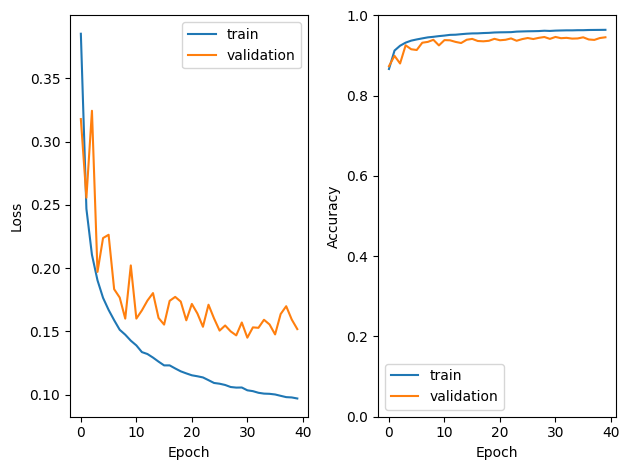

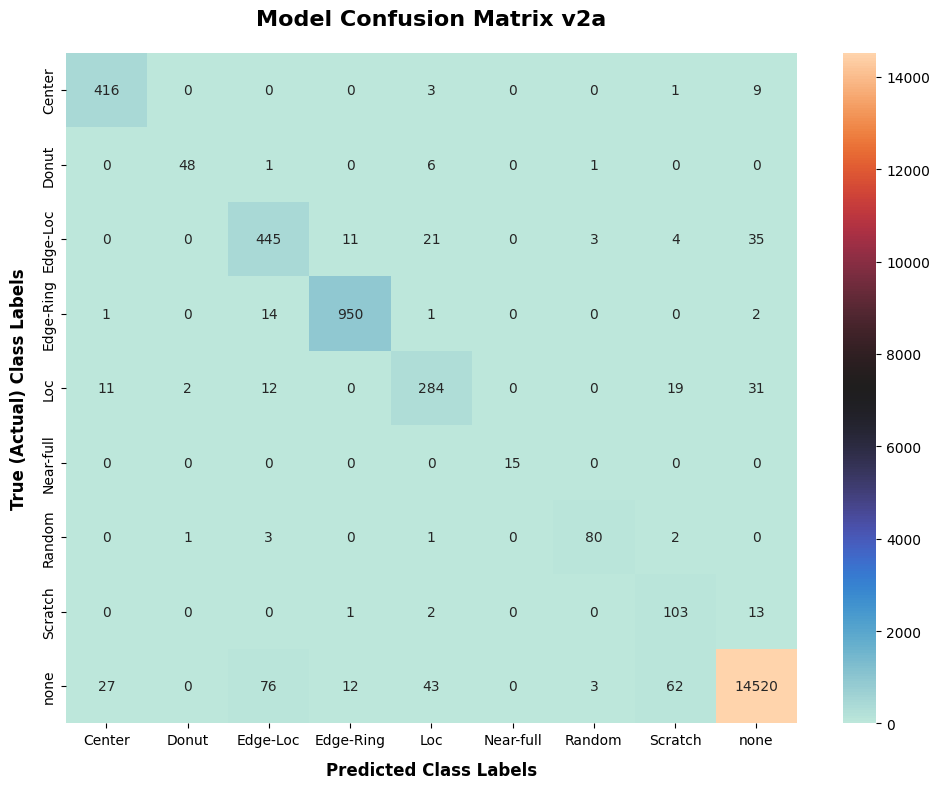

In [11]:
from sklearn.metrics import confusion_matrix


# Visualization of the learning curves
# Loss
plt.subplot(1, 2, 1)
plt.plot(history_v2a.history['loss'])
plt.plot(history_v2a.history['val_loss'])
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['train', 'validation'])
# Accuracy
plt.subplot(1, 2, 2)
plt.plot(history_v2a.history['accuracy'])
plt.plot(history_v2a.history['val_accuracy'])
plt.ylim([0.0, 1.0])
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['train', 'validation'])

plt.tight_layout()


# Save Modelv1b
modelv2a.save("taku_modelv2a.keras")

# Convert the history dictionary to a Pandas DataFrame
history_df = pd.DataFrame(history_v2a.history)

# Save to CSV
history_df.to_csv('history_modelv2a.csv', index=False)

# --- To load it back later ---
loaded_df = pd.read_csv('history_modelv2a.csv')


# Model Evaluation
X_test = X_test.astype(np.float32) 
y_test = np.array(y_test, dtype=np.float32)
test_loss, test_acc = modelv2a.evaluate(X_test, y_test, batch_size=128, verbose=1)
print(f"\nFinal Test Accuracy: {test_acc * 100:.2f}%")


# 1. Get raw probabilities for all 118,595 images
# The output will be a massive matrix of shape (118595, 9)
predictions = modelv2a.predict(X_test, batch_size=128, verbose=1)

# 2. Convert probabilities into final class choices (0 through 8)
# np.argmax looks at the 9 probabilities for each image and picks the highest one
predicted_classes = np.argmax(predictions, axis=1)

# 3. Convert your one-hot encoded test labels into standard class numbers too
true_classes = np.argmax(y_test, axis=1)

print("\nPredictions generated successfully!")
print(f"First 10 predicted classes: {predicted_classes[:10]}")
print(f"First 10 actual classes:    {true_classes[:10]}")



ClassMapping = ["Center","Donut","Edge-Loc","Edge-Ring","Loc","Near-full","Random","Scratch","none"]
predicted_classes = np.argmax(predictions, axis=1)

# 1. Generate the confusion matrix
cm = confusion_matrix(true_classes, predicted_classes)

# 2. Calculate per-class accuracy
# cm.diagonal() gets the correctly predicted count for each class
# cm.sum(axis=1) gets the total actual count for each class
class_accuracies = cm.diagonal() / cm.sum(axis=1)

# 3. Print the results clearly
print("Per-Class Accuracy:")
print("-" * 25)
for class_idx, acc in enumerate(class_accuracies):
    # Grab the actual name from your list using the index
    class_name = ClassMapping[class_idx]
    print(f"Class {class_name}: {acc * 100:.2f}%")
    
# Optional: Print the overall average of these class accuracies (Macro Average)
macro_accuracy = np.mean(class_accuracies)
print("-" * 25)
print(f"Average (Macro) Accuracy: {macro_accuracy * 100:.2f}%")



# 1. Calculate the raw confusion matrix numerical values
# (Assumes true_classes and predicted_classes are defined from the predict step)
cm = confusion_matrix(true_classes, predicted_classes)

# 2. Set up the figure size (10x8 inches works well for 9 classes)
plt.figure(figsize=(10, 8))

# 3. Create the colored heatmap
# annot=True plots the numbers inside each square
# fmt='d' forces plain integer format (no scientific notation)
# cmap='Blues' applies a light-to-dark blue gradient based on the numbers
class_names = ClassMapping

sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='icefire', 
    xticklabels=class_names, 
    yticklabels=class_names
)

# 4. Add clear labels and styling
plt.title('Model Confusion Matrix v2a', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Predicted Class Labels', fontsize=12, fontweight='bold', labelpad=10)
plt.ylabel('True (Actual) Class Labels', fontsize=12, fontweight='bold', labelpad=10)

# Adjust layout so labels don't get cut off
plt.tight_layout()

# 5. Render the plot on your screen
plt.show()

### Model Architecture (ModelV2b)
Skip connections to make the deeper stack easy to optimize

In [18]:
def res_block(x, filters, downsample=False):
    stride = 2 if downsample else 1
    shortcut = x
    y = layers.Conv2D(filters, 3, strides=stride, padding='same', use_bias=False)(x)
    y = layers.BatchNormalization()(y); y = layers.ReLU()(y)
    y = layers.Conv2D(filters, 3, strides=1, padding='same', use_bias=False)(y)
    y = layers.BatchNormalization()(y)
    if downsample or shortcut.shape[-1] != filters:                 # projection shortcut
        shortcut = layers.Conv2D(filters, 1, strides=stride, padding='same', use_bias=False)(shortcut)
        shortcut = layers.BatchNormalization()(shortcut)
    y = layers.add([y, shortcut])
    return layers.ReLU()(y)

inp = Input(shape=input_shape)
x = layers.Rescaling(1.0/2.0)(inp)
x = layers.Conv2D(16, 3, padding='same', use_bias=False)(x)         # stem, 54x54
x = layers.BatchNormalization()(x); x = layers.ReLU()(x)
x = res_block(x, 16)                                                # 54x54x16
x = res_block(x, 32,  downsample=True)                             # 27x27x32
x = res_block(x, 64,  downsample=True)                             # 14x14x64
x = res_block(x, 128, downsample=True)                             # 7x7x128
x = layers.Dropout(0.5)(x)
x = layers.Flatten()(x)
out = layers.Dense(num_classes, activation='softmax')(x)
modelv2b = models.Model(inp, out)

In [19]:
modelv2b.compile(
    optimizer= keras.optimizers.Adam(learning_rate=0.001, weight_decay=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


# Compute class weights from our augmented data
class_indices = np.argmax(y_balanced, axis=1)
total = len(class_indices)
num_classes = 9

class_weights = {}
for c in range(num_classes):
    count = np.sum(class_indices == c)
    class_weights[c] = total / (num_classes * count)

# Check what the model will see
ClassMapping = ["Center","Donut","Edge-Loc","Edge-Ring","Loc","Near-full","Random","Scratch","none"]
print(f"{'Class':<12} {'Count':>8} {'Weight':>8}")
print("-" * 30)
for c in range(num_classes):
    count = np.sum(class_indices == c)
    print(f"{ClassMapping[c]:<12} {count:>8,} {class_weights[c]:>8.3f}")


history_v2b = modelv2b.fit(
    x=X_balanced,
    y=y_balanced,
    epochs=40,
    batch_size=64,
    shuffle=True,
    verbose=1,
    validation_split=0.2,
)

Class           Count   Weight
------------------------------
Center         30,920    0.911
Donut           3,992    7.054
Edge-Loc       37,360    0.754
Edge-Ring      69,696    0.404
Loc            25,872    1.088
Near-full       1,072   26.268
Random          6,232    4.518
Scratch         8,592    3.277
none           69,696    0.404
Epoch 1/40
3168/3168 ━━━━━━━━━━━━━━━━━━━━ 674s 210ms/step - accuracy: 0.8859 - loss: 0.3422 - val_accuracy: 0.8982 - val_loss: 0.2760
Epoch 2/40
3168/3168 ━━━━━━━━━━━━━━━━━━━━ 660s 208ms/step - accuracy: 0.9323 - loss: 0.1934 - val_accuracy: 0.9236 - val_loss: 0.2129
Epoch 3/40
3168/3168 ━━━━━━━━━━━━━━━━━━━━ 652s 206ms/step - accuracy: 0.9445 - loss: 0.1575 - val_accuracy: 0.9269 - val_loss: 0.2083
Epoch 4/40
3168/3168 ━━━━━━━━━━━━━━━━━━━━ 658s 208ms/step - accuracy: 0.9506 - loss: 0.1383 - val_accuracy: 0.9339 - val_loss: 0.1833
Epoch 5/40
3168/3168 ━━━━━━━━━━━━━━━━━━━━ 655s 207ms/step - accuracy: 0.9549 - loss: 0.1260 - val_accuracy: 0.9347 - val_lo

136/136 ━━━━━━━━━━━━━━━━━━━━ 11s 81ms/step - accuracy: 0.9806 - loss: 0.1205

Final Test Accuracy: 98.06%
136/136 ━━━━━━━━━━━━━━━━━━━━ 11s 81ms/step

Predictions generated successfully!
First 10 predicted classes: [8 8 8 8 8 3 8 0 4 8]
First 10 actual classes:    [8 8 8 8 8 3 8 0 4 8]
Per-Class Accuracy:
-------------------------
Class Center: 94.17%
Class Donut: 85.71%
Class Edge-Loc: 84.59%
Class Edge-Ring: 98.97%
Class Loc: 74.09%
Class Near-full: 93.33%
Class Random: 93.10%
Class Scratch: 73.95%
Class none: 99.44%
-------------------------
Average (Macro) Accuracy: 88.60%


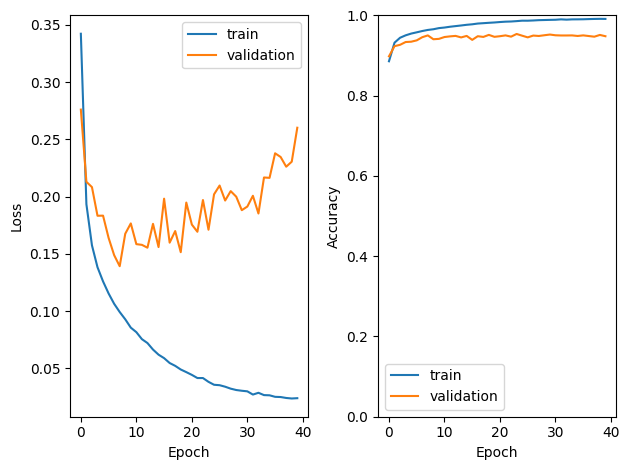

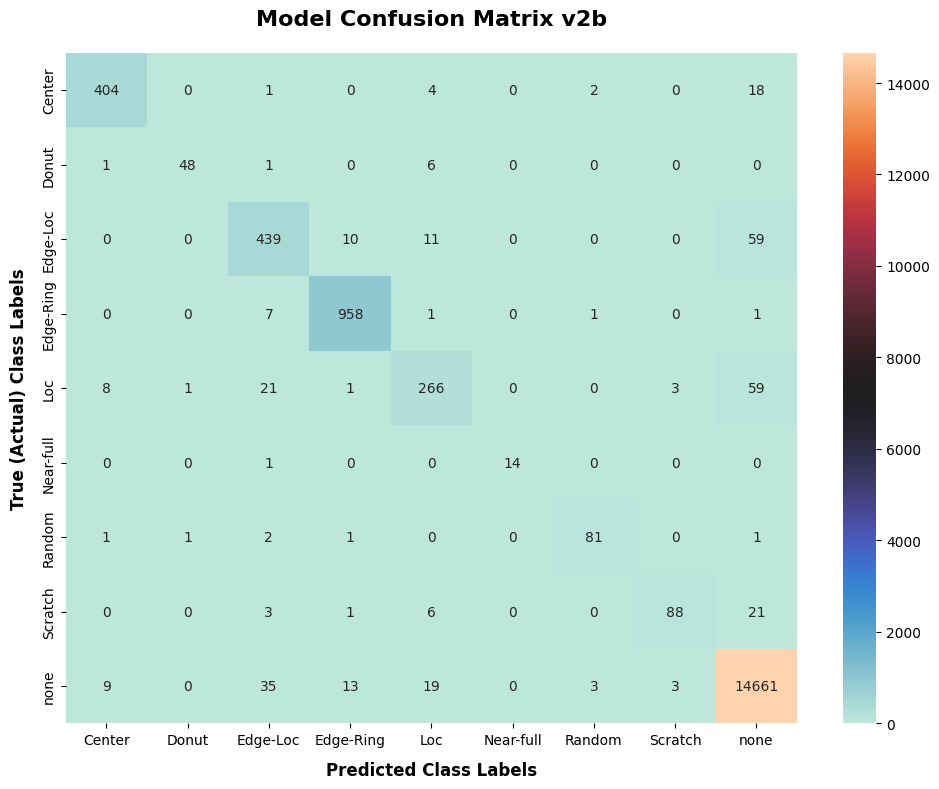

In [20]:
from sklearn.metrics import confusion_matrix


# Visualization of the learning curves
# Loss
plt.subplot(1, 2, 1)
plt.plot(history_v2b.history['loss'])
plt.plot(history_v2b.history['val_loss'])
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['train', 'validation'])
# Accuracy
plt.subplot(1, 2, 2)
plt.plot(history_v2b.history['accuracy'])
plt.plot(history_v2b.history['val_accuracy'])
plt.ylim([0.0, 1.0])
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['train', 'validation'])

plt.tight_layout()


# Save Modelv1b
modelv2b.save("taku_modelv2b.keras")

# Convert the history dictionary to a Pandas DataFrame
history_df = pd.DataFrame(history_v2b.history)

# Save to CSV
history_df.to_csv('history_modelv2b.csv', index=False)

# --- To load it back later ---
loaded_df = pd.read_csv('history_modelv2b.csv')


# Model Evaluation
X_test = X_test.astype(np.float32) 
y_test = np.array(y_test, dtype=np.float32)
test_loss, test_acc = modelv2b.evaluate(X_test, y_test, batch_size=128, verbose=1)
print(f"\nFinal Test Accuracy: {test_acc * 100:.2f}%")



# 1. Get raw probabilities for all 118,595 images
# The output will be a massive matrix of shape (118595, 9)
predictions = modelv2b.predict(X_test, batch_size=128, verbose=1)

# 2. Convert probabilities into final class choices (0 through 8)
# np.argmax looks at the 9 probabilities for each image and picks the highest one
predicted_classes = np.argmax(predictions, axis=1)

# 3. Convert your one-hot encoded test labels into standard class numbers too
true_classes = np.argmax(y_test, axis=1)

print("\nPredictions generated successfully!")
print(f"First 10 predicted classes: {predicted_classes[:10]}")
print(f"First 10 actual classes:    {true_classes[:10]}")


ClassMapping = ["Center","Donut","Edge-Loc","Edge-Ring","Loc","Near-full","Random","Scratch","none"]
predicted_classes = np.argmax(predictions, axis=1)

# 1. Generate the confusion matrix
cm = confusion_matrix(true_classes, predicted_classes)

# 2. Calculate per-class accuracy
# cm.diagonal() gets the correctly predicted count for each class
# cm.sum(axis=1) gets the total actual count for each class
class_accuracies = cm.diagonal() / cm.sum(axis=1)

# 3. Print the results clearly
print("Per-Class Accuracy:")
print("-" * 25)
for class_idx, acc in enumerate(class_accuracies):
    # Grab the actual name from your list using the index
    class_name = ClassMapping[class_idx]
    print(f"Class {class_name}: {acc * 100:.2f}%")
    
# Optional: Print the overall average of these class accuracies (Macro Average)
macro_accuracy = np.mean(class_accuracies)
print("-" * 25)
print(f"Average (Macro) Accuracy: {macro_accuracy * 100:.2f}%")



# 1. Calculate the raw confusion matrix numerical values
# (Assumes true_classes and predicted_classes are defined from the predict step)
cm = confusion_matrix(true_classes, predicted_classes)

# 2. Set up the figure size (10x8 inches works well for 9 classes)
plt.figure(figsize=(10, 8))

# 3. Create the colored heatmap
# annot=True plots the numbers inside each square
# fmt='d' forces plain integer format (no scientific notation)
# cmap='Blues' applies a light-to-dark blue gradient based on the numbers
class_names = ClassMapping

sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='icefire', 
    xticklabels=class_names, 
    yticklabels=class_names
)

# 4. Add clear labels and styling
plt.title('Model Confusion Matrix v2b', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Predicted Class Labels', fontsize=12, fontweight='bold', labelpad=10)
plt.ylabel('True (Actual) Class Labels', fontsize=12, fontweight='bold', labelpad=10)

# Adjust layout so labels don't get cut off
plt.tight_layout()

# 5. Render the plot on your screen
plt.show()

### Model Architecture (ModelV2c)
Squeeze-and-Excitation attention lets the network reweight which feature maps matter per image. 

In [12]:
class SEBlock(layers.Layer):
    """Channel attention: GAP -> bottleneck FC -> sigmoid -> rescale channels."""
    def __init__(self, reduction=4, **kwargs):
        super().__init__(**kwargs)
        self.reduction = reduction

    def build(self, input_shape):
        filters = input_shape[-1]
        bottleneck = max(filters // self.reduction, 4)   # floor for your small filter counts
        self.gap   = layers.GlobalAveragePooling2D()
        self.fc1   = layers.Dense(bottleneck, activation='relu')
        self.fc2   = layers.Dense(filters, activation='sigmoid')
        self.resh  = layers.Reshape((1, 1, filters))

    def call(self, x):
        s = self.resh(self.fc2(self.fc1(self.gap(x))))
        return x * s                                     # broadcasts (b,1,1,C) over (b,h,w,C)

    def get_config(self):
        cfg = super().get_config(); cfg.update({"reduction": self.reduction}); return cfg


modelv2c = models.Sequential([
    # Input & MATLAB-style normalization (Min=0, Max=2)
    layers.Input(shape=input_shape),
    layers.Rescaling(scale=1.0/2.0),

    # Block 1: 54x54x3 -> 27x27x8 after MaxPool
    layers.Conv2D(8, (3, 3), padding='same'),
    layers.BatchNormalization(),
    layers.ReLU(),
    SEBlock(),  
    layers.MaxPooling2D(pool_size=(2, 2)),
    
    # Block 2: 27x27x8 -> 13x13x16 after MaxPool
    layers.Conv2D(16, (3, 3), padding='same'),
    layers.BatchNormalization(),
    layers.ReLU(),
    SEBlock(),  
    layers.MaxPooling2D(pool_size=(2, 2)),
    
    # Block 3: 13x13x16 -> 6x6x32 after MaxPool
    layers.Conv2D(32, (3, 3), padding='same'),
    layers.BatchNormalization(),
    layers.ReLU(),
    SEBlock(),  
    layers.MaxPooling2D(pool_size=(2, 2)),
    
    # Block 4: Stays 6x6x64
    layers.Conv2D(64, (3, 3), padding='same'),
    layers.BatchNormalization(),
    layers.ReLU(),
    SEBlock(),  
    
    layers.Dropout(0.5),
    layers.Flatten(),                  # Flattens 6x6x64 into a 2304-element vector
    layers.Dense(num_classes),         # 9 outputs
    layers.Activation('softmax')
])

In [13]:
modelv2c.compile(
    optimizer= keras.optimizers.Adam(learning_rate=0.001, weight_decay=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


# Compute class weights from our augmented data
class_indices = np.argmax(y_balanced, axis=1)
total = len(class_indices)
num_classes = 9

class_weights = {}
for c in range(num_classes):
    count = np.sum(class_indices == c)
    class_weights[c] = total / (num_classes * count)

# Check what the model will see
ClassMapping = ["Center","Donut","Edge-Loc","Edge-Ring","Loc","Near-full","Random","Scratch","none"]
print(f"{'Class':<12} {'Count':>8} {'Weight':>8}")
print("-" * 30)
for c in range(num_classes):
    count = np.sum(class_indices == c)
    print(f"{ClassMapping[c]:<12} {count:>8,} {class_weights[c]:>8.3f}")


history_v2c = modelv2c.fit(
    x=X_balanced,
    y=y_balanced,
    epochs=40,
    batch_size=64,
    shuffle=True,
    verbose=1,
    validation_split=0.2,
)

Class           Count   Weight
------------------------------
Center         30,920    0.911
Donut           3,992    7.054
Edge-Loc       37,360    0.754
Edge-Ring      69,696    0.404
Loc            25,872    1.088
Near-full       1,072   26.268
Random          6,232    4.518
Scratch         8,592    3.277
none           69,696    0.404
Epoch 1/40
3168/3168 ━━━━━━━━━━━━━━━━━━━━ 180s 54ms/step - accuracy: 0.8865 - loss: 0.3179 - val_accuracy: 0.8478 - val_loss: 0.4127
Epoch 2/40
3168/3168 ━━━━━━━━━━━━━━━━━━━━ 166s 53ms/step - accuracy: 0.9246 - loss: 0.2052 - val_accuracy: 0.9075 - val_loss: 0.2391
Epoch 3/40
3168/3168 ━━━━━━━━━━━━━━━━━━━━ 174s 55ms/step - accuracy: 0.9352 - loss: 0.1755 - val_accuracy: 0.9194 - val_loss: 0.2098
Epoch 4/40
3168/3168 ━━━━━━━━━━━━━━━━━━━━ 177s 56ms/step - accuracy: 0.9421 - loss: 0.1586 - val_accuracy: 0.9152 - val_loss: 0.2170
Epoch 5/40
3168/3168 ━━━━━━━━━━━━━━━━━━━━ 171s 54ms/step - accuracy: 0.9455 - loss: 0.1471 - val_accuracy: 0.9164 - val_loss: 0

136/136 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.9811 - loss: 0.0680

Final Test Accuracy: 98.11%
136/136 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step

Predictions generated successfully!
First 10 predicted classes: [8 8 8 8 8 3 8 0 4 8]
First 10 actual classes:    [8 8 8 8 8 3 8 0 4 8]
Per-Class Accuracy:
-------------------------
Class Center: 95.57%
Class Donut: 85.71%
Class Edge-Loc: 84.78%
Class Edge-Ring: 98.45%
Class Loc: 76.32%
Class Near-full: 93.33%
Class Random: 98.85%
Class Scratch: 67.23%
Class none: 99.46%
-------------------------
Average (Macro) Accuracy: 88.86%


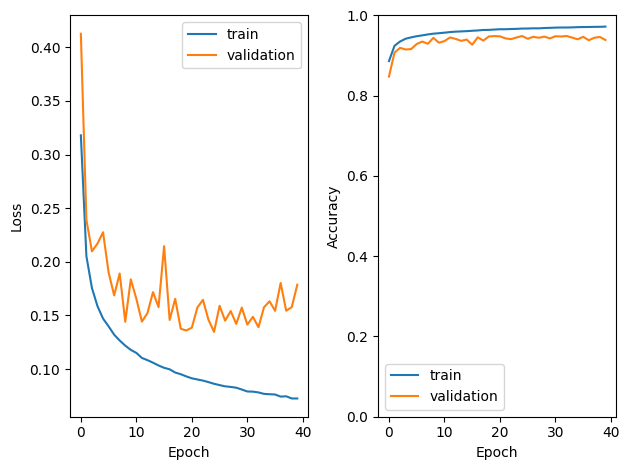

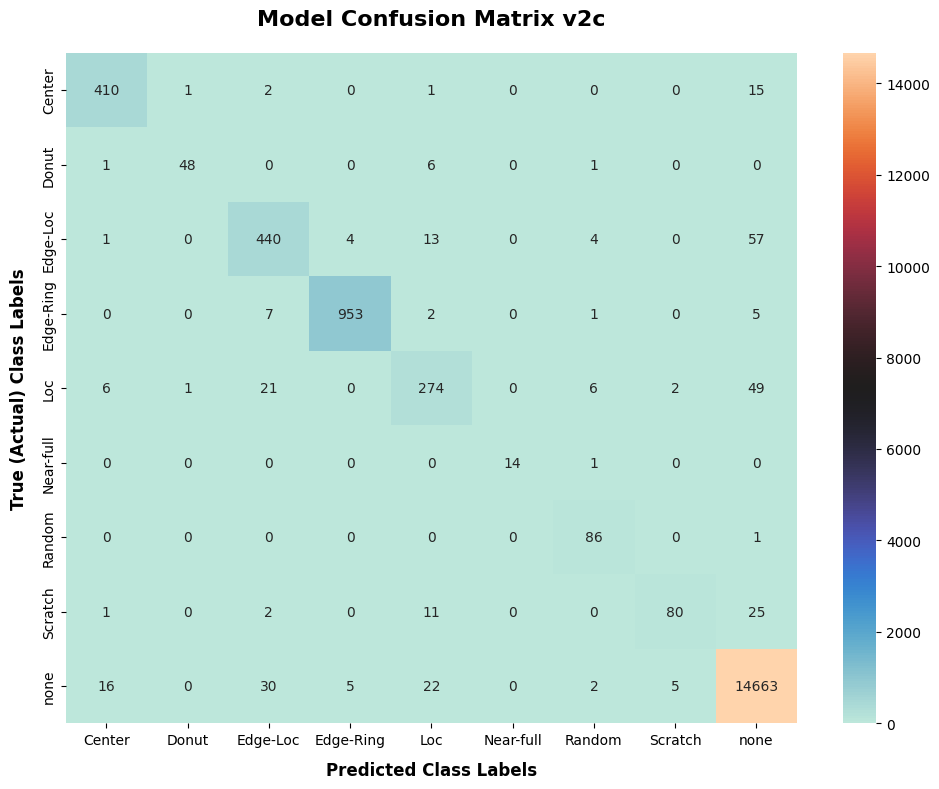

In [14]:
from sklearn.metrics import confusion_matrix


# Visualization of the learning curves
# Loss
plt.subplot(1, 2, 1)
plt.plot(history_v2c.history['loss'])
plt.plot(history_v2c.history['val_loss'])
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['train', 'validation'])
# Accuracy
plt.subplot(1, 2, 2)
plt.plot(history_v2c.history['accuracy'])
plt.plot(history_v2c.history['val_accuracy'])
plt.ylim([0.0, 1.0])
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['train', 'validation'])

plt.tight_layout()


# Save Modelv1b
modelv2c.save("taku_modelv2c.keras")

# Convert the history dictionary to a Pandas DataFrame
history_df = pd.DataFrame(history_v2c.history)

# Save to CSV
history_df.to_csv('history_modelv2c.csv', index=False)

# --- To load it back later ---
loaded_df = pd.read_csv('history_modelv2c.csv')


# Model Evaluation
X_test = X_test.astype(np.float32) 
y_test = np.array(y_test, dtype=np.float32)
test_loss, test_acc = modelv2c.evaluate(X_test, y_test, batch_size=128, verbose=1)
print(f"\nFinal Test Accuracy: {test_acc * 100:.2f}%")


# 1. Get raw probabilities for all 118,595 images
# The output will be a massive matrix of shape (118595, 9)
predictions = modelv2c.predict(X_test, batch_size=128, verbose=1)

# 2. Convert probabilities into final class choices (0 through 8)
# np.argmax looks at the 9 probabilities for each image and picks the highest one
predicted_classes = np.argmax(predictions, axis=1)

# 3. Convert your one-hot encoded test labels into standard class numbers too
true_classes = np.argmax(y_test, axis=1)

print("\nPredictions generated successfully!")
print(f"First 10 predicted classes: {predicted_classes[:10]}")
print(f"First 10 actual classes:    {true_classes[:10]}")



ClassMapping = ["Center","Donut","Edge-Loc","Edge-Ring","Loc","Near-full","Random","Scratch","none"]
predicted_classes = np.argmax(predictions, axis=1)

# 1. Generate the confusion matrix
cm = confusion_matrix(true_classes, predicted_classes)

# 2. Calculate per-class accuracy
# cm.diagonal() gets the correctly predicted count for each class
# cm.sum(axis=1) gets the total actual count for each class
class_accuracies = cm.diagonal() / cm.sum(axis=1)

# 3. Print the results clearly
print("Per-Class Accuracy:")
print("-" * 25)
for class_idx, acc in enumerate(class_accuracies):
    # Grab the actual name from your list using the index
    class_name = ClassMapping[class_idx]
    print(f"Class {class_name}: {acc * 100:.2f}%")
    
# Optional: Print the overall average of these class accuracies (Macro Average)
macro_accuracy = np.mean(class_accuracies)
print("-" * 25)
print(f"Average (Macro) Accuracy: {macro_accuracy * 100:.2f}%")



# 1. Calculate the raw confusion matrix numerical values
# (Assumes true_classes and predicted_classes are defined from the predict step)
cm = confusion_matrix(true_classes, predicted_classes)

# 2. Set up the figure size (10x8 inches works well for 9 classes)
plt.figure(figsize=(10, 8))

# 3. Create the colored heatmap
# annot=True plots the numbers inside each square
# fmt='d' forces plain integer format (no scientific notation)
# cmap='Blues' applies a light-to-dark blue gradient based on the numbers
class_names = ClassMapping

sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='icefire', 
    xticklabels=class_names, 
    yticklabels=class_names
)

# 4. Add clear labels and styling
plt.title('Model Confusion Matrix v2c', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Predicted Class Labels', fontsize=12, fontweight='bold', labelpad=10)
plt.ylabel('True (Actual) Class Labels', fontsize=12, fontweight='bold', labelpad=10)

# Adjust layout so labels don't get cut off
plt.tight_layout()

# 5. Render the plot on your screen
plt.show()

### Cross Training between Augmented data and Deep Learning Models

In [15]:
num_classes = 9

# Architecture definition (v2)

inputs = keras.Input((54,54,3))

# Slice to keep only the last two channels (indices 1 and 2)
# The syntax [:, :, :, 0:2] means: [batch, height, width, channels 0 through 1]
x = layers.Lambda(lambda x: x[:, :, :, 1:])(inputs)

x = keras.layers.Conv2D(32, 3, padding='same')(x)
x = keras.layers.Activation('relu')(x)
x = keras.layers.MaxPooling2D(3, strides=3, padding='same')(x)

x = keras.layers.Conv2D(64, 3, padding='same')(x)
x = keras.layers.Activation('relu')(x)

x = keras.layers.GlobalMaxPooling2D()(x)

outputs = keras.layers.Dense(num_classes, activation='softmax')(x)
manu = keras.Model(inputs, outputs)

In [16]:
manu.compile(
    optimizer= keras.optimizers.Adam(learning_rate=0.001, weight_decay=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


# Compute class weights from our augmented data
class_indices = np.argmax(y_balanced, axis=1)
total = len(class_indices)
num_classes = 9

class_weights = {}
for c in range(num_classes):
    count = np.sum(class_indices == c)
    class_weights[c] = total / (num_classes * count)

# Check what the model will see
ClassMapping = ["Center","Donut","Edge-Loc","Edge-Ring","Loc","Near-full","Random","Scratch","none"]
print(f"{'Class':<12} {'Count':>8} {'Weight':>8}")
print("-" * 30)
for c in range(num_classes):
    count = np.sum(class_indices == c)
    print(f"{ClassMapping[c]:<12} {count:>8,} {class_weights[c]:>8.3f}")


history_manu = manu.fit(
    x=X_balanced,
    y=y_balanced,
    epochs=40,
    batch_size=64,
    shuffle=True,
    verbose=1,
    validation_split=0.2,
)

Class           Count   Weight
------------------------------
Center         30,920    0.911
Donut           3,992    7.054
Edge-Loc       37,360    0.754
Edge-Ring      69,696    0.404
Loc            25,872    1.088
Near-full       1,072   26.268
Random          6,232    4.518
Scratch         8,592    3.277
none           69,696    0.404
Epoch 1/40
3168/3168 ━━━━━━━━━━━━━━━━━━━━ 108s 33ms/step - accuracy: 0.8625 - loss: 0.3874 - val_accuracy: 0.8665 - val_loss: 0.3391
Epoch 2/40
3168/3168 ━━━━━━━━━━━━━━━━━━━━ 91s 29ms/step - accuracy: 0.9069 - loss: 0.2539 - val_accuracy: 0.8873 - val_loss: 0.2875
Epoch 3/40
3168/3168 ━━━━━━━━━━━━━━━━━━━━ 87s 27ms/step - accuracy: 0.9178 - loss: 0.2235 - val_accuracy: 0.8747 - val_loss: 0.3191
Epoch 4/40
3168/3168 ━━━━━━━━━━━━━━━━━━━━ 86s 27ms/step - accuracy: 0.9243 - loss: 0.2059 - val_accuracy: 0.8934 - val_loss: 0.2736
Epoch 5/40
3168/3168 ━━━━━━━━━━━━━━━━━━━━ 86s 27ms/step - accuracy: 0.9296 - loss: 0.1916 - val_accuracy: 0.9004 - val_loss: 0.256

136/136 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.9653 - loss: 0.1125

Final Test Accuracy: 96.53%
136/136 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step

Predictions generated successfully!
First 10 predicted classes: [8 8 8 8 8 3 8 0 2 8]
First 10 actual classes:    [8 8 8 8 8 3 8 0 4 8]
Per-Class Accuracy:
-------------------------
Class Center: 90.91%
Class Donut: 73.21%
Class Edge-Loc: 80.73%
Class Edge-Ring: 98.55%
Class Loc: 73.82%
Class Near-full: 80.00%
Class Random: 96.55%
Class Scratch: 76.47%
Class none: 97.94%
-------------------------
Average (Macro) Accuracy: 85.35%


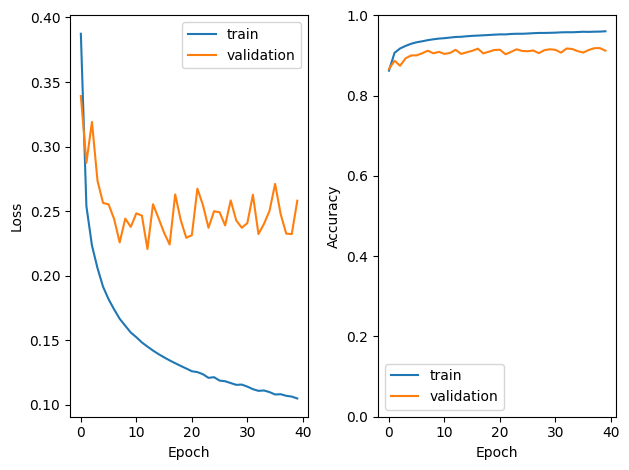

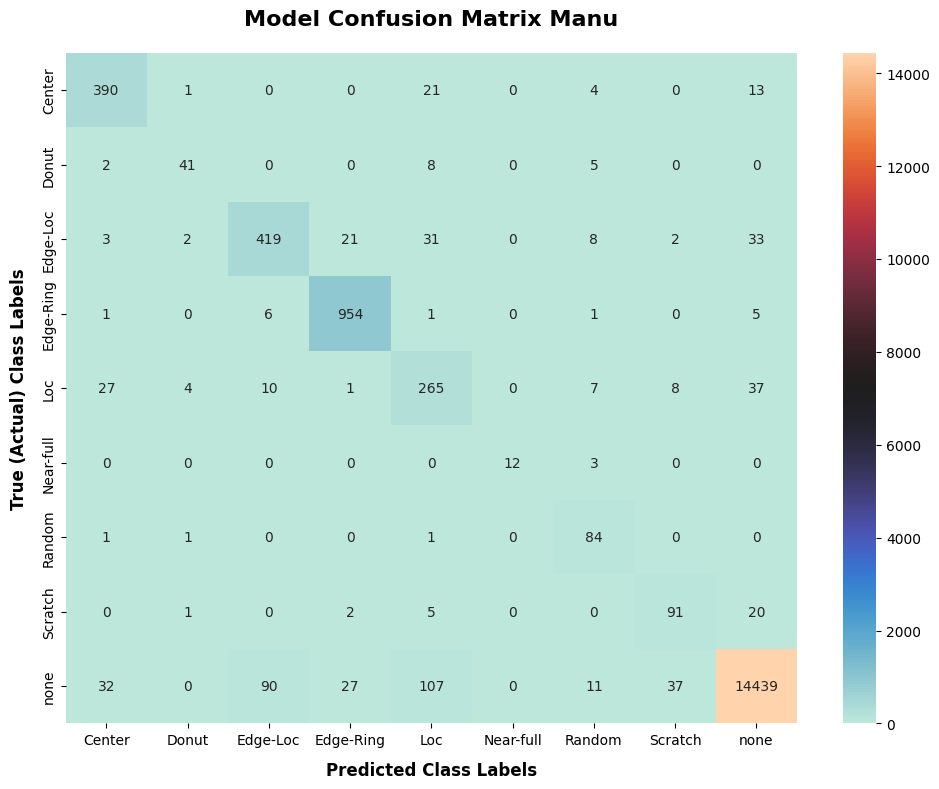

In [17]:
from sklearn.metrics import confusion_matrix


# Visualization of the learning curves
# Loss
plt.subplot(1, 2, 1)
plt.plot(history_manu.history['loss'])
plt.plot(history_manu.history['val_loss'])
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['train', 'validation'])
# Accuracy
plt.subplot(1, 2, 2)
plt.plot(history_manu.history['accuracy'])
plt.plot(history_manu.history['val_accuracy'])
plt.ylim([0.0, 1.0])
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['train', 'validation'])

plt.tight_layout()


# Save Modelv1b
manu.save("manu_model.keras")

# Convert the history dictionary to a Pandas DataFrame
history_df = pd.DataFrame(history_manu.history)

# Save to CSV
history_df.to_csv('history_manu.csv', index=False)

# --- To load it back later ---
loaded_df = pd.read_csv('history_manu.csv')


# Model Evaluation
X_test = X_test.astype(np.float32) 
y_test = np.array(y_test, dtype=np.float32)
test_loss, test_acc = manu.evaluate(X_test, y_test, batch_size=128, verbose=1)
print(f"\nFinal Test Accuracy: {test_acc * 100:.2f}%")


# 1. Get raw probabilities for all 118,595 images
# The output will be a massive matrix of shape (118595, 9)
predictions = manu.predict(X_test, batch_size=128, verbose=1)

# 2. Convert probabilities into final class choices (0 through 8)
# np.argmax looks at the 9 probabilities for each image and picks the highest one
predicted_classes = np.argmax(predictions, axis=1)

# 3. Convert your one-hot encoded test labels into standard class numbers too
true_classes = np.argmax(y_test, axis=1)

print("\nPredictions generated successfully!")
print(f"First 10 predicted classes: {predicted_classes[:10]}")
print(f"First 10 actual classes:    {true_classes[:10]}")



ClassMapping = ["Center","Donut","Edge-Loc","Edge-Ring","Loc","Near-full","Random","Scratch","none"]
predicted_classes = np.argmax(predictions, axis=1)

# 1. Generate the confusion matrix
cm = confusion_matrix(true_classes, predicted_classes)

# 2. Calculate per-class accuracy
# cm.diagonal() gets the correctly predicted count for each class
# cm.sum(axis=1) gets the total actual count for each class
class_accuracies = cm.diagonal() / cm.sum(axis=1)

# 3. Print the results clearly
print("Per-Class Accuracy:")
print("-" * 25)
for class_idx, acc in enumerate(class_accuracies):
    # Grab the actual name from your list using the index
    class_name = ClassMapping[class_idx]
    print(f"Class {class_name}: {acc * 100:.2f}%")
    
# Optional: Print the overall average of these class accuracies (Macro Average)
macro_accuracy = np.mean(class_accuracies)
print("-" * 25)
print(f"Average (Macro) Accuracy: {macro_accuracy * 100:.2f}%")



# 1. Calculate the raw confusion matrix numerical values
# (Assumes true_classes and predicted_classes are defined from the predict step)
cm = confusion_matrix(true_classes, predicted_classes)

# 2. Set up the figure size (10x8 inches works well for 9 classes)
plt.figure(figsize=(10, 8))

# 3. Create the colored heatmap
# annot=True plots the numbers inside each square
# fmt='d' forces plain integer format (no scientific notation)
# cmap='Blues' applies a light-to-dark blue gradient based on the numbers
class_names = ClassMapping

sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='icefire', 
    xticklabels=class_names, 
    yticklabels=class_names
)

# 4. Add clear labels and styling
plt.title('Model Confusion Matrix Manu', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Predicted Class Labels', fontsize=12, fontweight='bold', labelpad=10)
plt.ylabel('True (Actual) Class Labels', fontsize=12, fontweight='bold', labelpad=10)

# Adjust layout so labels don't get cut off
plt.tight_layout()

# 5. Render the plot on your screen
plt.show()

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, Input
import numpy as np
import seaborn as sns
import cv2
import gc
from sklearn.metrics import classification_report, confusion_matrix

"""
evaluate_models.py

Batch-evaluate one or more trained Keras classifiers on the ORIGINAL (imbalanced)
test set and report precision / recall / F1 per class, plus macro / weighted
summaries and confusion matrices.

Why the imbalanced test set: per-class *recall* on a re-balanced split flatters
minority performance (the Scratch / class-weight false-positive trap). Precision
and F1 on the true distribution are the honest arbiter of whether a change helped.

Drop into a notebook cell, or `from evaluate_models import evaluate_models`.
"""


def _as_label_vector(y, num_classes):
    """Accept one-hot (N, C) or integer (N,) labels and return integer (N,)."""
    y = np.asarray(y)
    if y.ndim == 2:
        return y.argmax(axis=1).astype(int)
    return y.astype(int)


def _load_if_path(entry, custom_objects):
    """If entry is a path string, load the Keras model (compile=False, since we
    only predict); otherwise return it unchanged. TensorFlow is imported lazily so
    evaluating in-memory models needs no TF import. Returns (model, from_disk)."""
    if isinstance(entry, str):
        from tensorflow.keras.models import load_model
        return load_model(entry, custom_objects=custom_objects, compile=False), True
    return entry, False


def evaluate_models(
    models,
    X_test,
    y_test,
    class_names,
    batch_size=128,
    preprocess=None,
    custom_objects=None,
    print_reports=True,
):
    """
    Parameters
    ----------
    models : dict {name: model_or_path} OR list of (name, model_or_path).
        Each value is either a live Keras model or a path to a saved model
        (.keras / .h5). Path entries are loaded one at a time and freed straight
        after evaluation, so a long list of saved models won't blow up RAM.
    X_test, y_test : the ORIGINAL imbalanced test arrays.
        y_test may be one-hot (N, C) or integer (N,).
    class_names : list[str]
        Class labels in the SAME index order as your training label_to_int map
        (index i == class i). This is what keeps every model's rows aligned and
        comparable; never derive it from the test set alone.
    batch_size : int, predict batch size (keeps memory flat on CPU/Colab).
    preprocess : callable(X) -> X, optional. Applied to X_test before predict for
        ALL models. Default identity — your current models keep rescaling / coord
        channels / SE as internal layers, so they take the raw (N, 54, 54, 3).
    custom_objects : dict, optional. Needed only when loading models from disk that
        use custom layers, e.g. {"AddCoordChannels": AddCoordChannels, "SEBlock": SEBlock}.

    Returns
    -------
    summary  : pd.DataFrame  (rows = models; accuracy, macro/weighted P/R/F1)
    per_class: dict[str, pd.DataFrame] with keys "f1", "precision", "recall",
               each indexed by class with one column per model.
    results  : dict[name] -> {"report": dict, "confusion_matrix": np.ndarray, "y_pred": np.ndarray}
    """
    items = list(models.items()) if isinstance(models, dict) else list(models)

    num_classes = len(class_names)
    labels = list(range(num_classes))

    # Coerce once (X is shared across models) so we don't copy a large array per loop.
    X = np.asarray(X_test, dtype=np.float32)
    if preprocess is not None:
        X = preprocess(X)
    y_true = _as_label_vector(y_test, num_classes)

    results, summary_rows = {}, {}
    f1_cols, prec_cols, rec_cols = {}, {}, {}

    for name, entry in items:
        model, from_disk = _load_if_path(entry, custom_objects)

        probs = model.predict(X, batch_size=batch_size, verbose=0)
        y_pred = np.asarray(probs).argmax(axis=1)

        # labels=range(C) forces all 9 rows to appear in fixed order even if a
        # class gets zero predictions; zero_division=0 stops precision NaNs.
        report = classification_report(
            y_true, y_pred, labels=labels, target_names=class_names,
            output_dict=True, zero_division=0,
        )
        cm = confusion_matrix(y_true, y_pred, labels=labels)

        results[name] = {"report": report, "confusion_matrix": cm, "y_pred": y_pred}
        summary_rows[name] = {
            "accuracy":    report["accuracy"],
            "macro_P":     report["macro avg"]["precision"],
            "macro_R":     report["macro avg"]["recall"],
            "macro_F1":    report["macro avg"]["f1-score"],
            "weighted_F1": report["weighted avg"]["f1-score"],
        }
        f1_cols[name]   = {c: report[c]["f1-score"]  for c in class_names}
        prec_cols[name] = {c: report[c]["precision"] for c in class_names}
        rec_cols[name]  = {c: report[c]["recall"]    for c in class_names}

        if print_reports:
            print(f"\n{'=' * 60}\n{name}\n{'=' * 60}")
            print(classification_report(
                y_true, y_pred, labels=labels, target_names=class_names,
                digits=3, zero_division=0,
            ))

        if from_disk:          # free disk-loaded models immediately
            del model
            gc.collect()

    summary = pd.DataFrame(summary_rows).T[
        ["accuracy", "macro_P", "macro_R", "macro_F1", "weighted_F1"]
    ].round(4)
    per_class = {
        "f1":        pd.DataFrame(f1_cols).reindex(class_names).round(4),
        "precision": pd.DataFrame(prec_cols).reindex(class_names).round(4),
        "recall":    pd.DataFrame(rec_cols).reindex(class_names).round(4),
    }

    if print_reports:
        print(f"\n{'=' * 60}\nSummary (sorted by macro F1)\n{'=' * 60}")
        print(summary.sort_values("macro_F1", ascending=False).to_string())
        print(f"\nPer-class F1  (rows = class, cols = model)\n{'-' * 60}")
        print(per_class["f1"].to_string())
        print(f"\nPer-class precision  (the metric class weights quietly cost you)\n{'-' * 60}")
        print(per_class["precision"].to_string())

    return summary, per_class, results


def plot_confusion_matrix(results, name, class_names, normalize=True, ax=None):
    """Row-normalized confusion matrix for one model: each row sums to 1, so the
    off-diagonal cells show where a TRUE class's wafers actually went (e.g. how much
    Loc bleeds into Edge-Loc). Pass normalize=False for raw counts."""
    import matplotlib.pyplot as plt

    cm = results[name]["confusion_matrix"].astype(float)
    if normalize:
        row = cm.sum(axis=1, keepdims=True)
        cm = np.divide(cm, row, out=np.zeros_like(cm), where=row != 0)

    if ax is None:
        _, ax = plt.subplots(figsize=(7, 6))
    ax.imshow(cm, cmap="Blues", vmin=0, vmax=1 if normalize else None)
    ax.set_xticks(range(len(class_names)))
    ax.set_xticklabels(class_names, rotation=45, ha="right")
    ax.set_yticks(range(len(class_names)))
    ax.set_yticklabels(class_names)
    ax.set_xlabel("predicted")
    ax.set_ylabel("true")
    ax.set_title(f"{name} — confusion matrix" + (" (row-normalized)" if normalize else ""))

    thresh = 0.5 if normalize else cm.max() / 2.0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            v = cm[i, j]
            if v > 0:
                ax.text(j, i, f"{v:.2f}" if normalize else f"{int(v)}",
                        ha="center", va="center", fontsize=8,
                        color="white" if v > thresh else "black")
    import matplotlib.pyplot as _plt
    _plt.tight_layout()
    return ax


In [2]:
class AddCoordChannels(layers.Layer):
    """Concatenate normalized x, y (and optional radial r) channels to the input."""
    def __init__(self, with_r=True, **kwargs):
        super().__init__(**kwargs)
        self.with_r = with_r

    def call(self, inputs):
        batch = tf.shape(inputs)[0]
        h, w = inputs.shape[1], inputs.shape[2]          # static (54, 54)
        ones = tf.ones((batch, h, w, 1), dtype=inputs.dtype)
        xx = tf.cast(tf.reshape(tf.linspace(-1.0, 1.0, w), (1, 1, w, 1)), inputs.dtype)
        yy = tf.cast(tf.reshape(tf.linspace(-1.0, 1.0, h), (1, h, 1, 1)), inputs.dtype)
        xx, yy = ones * xx, ones * yy                    # (batch, h, w, 1) each
        out = tf.concat([inputs, xx, yy], axis=-1)
        if self.with_r:
            rr = tf.sqrt(tf.square(xx) + tf.square(yy)) / tf.cast(tf.sqrt(2.0), inputs.dtype)
            out = tf.concat([out, rr], axis=-1)
        return out                                       # 3 channels -> 6

    def get_config(self):
        cfg = super().get_config(); cfg.update({"with_r": self.with_r}); return cfg

In [3]:
class SEBlock(layers.Layer):
    """Channel attention: GAP -> bottleneck FC -> sigmoid -> rescale channels."""
    def __init__(self, reduction=4, **kwargs):
        super().__init__(**kwargs)
        self.reduction = reduction

    def build(self, input_shape):
        filters = input_shape[-1]
        bottleneck = max(filters // self.reduction, 4)   # floor for your small filter counts
        self.gap   = layers.GlobalAveragePooling2D()
        self.fc1   = layers.Dense(bottleneck, activation='relu')
        self.fc2   = layers.Dense(filters, activation='sigmoid')
        self.resh  = layers.Reshape((1, 1, filters))

    def call(self, x):
        s = self.resh(self.fc2(self.fc1(self.gap(x))))
        return x * s                                     # broadcasts (b,1,1,C) over (b,h,w,C)

    def get_config(self):
        cfg = super().get_config(); cfg.update({"reduction": self.reduction}); return cfg



baseline
              precision    recall  f1-score   support

      Center      0.935     0.946     0.941       429
       Donut      0.904     0.839     0.870        56
    Edge-Loc      0.828     0.842     0.835       519
   Edge-Ring      0.976     0.980     0.978       968
         Loc      0.797     0.788     0.793       359
   Near-full      0.933     0.933     0.933        15
      Random      0.842     0.920     0.879        87
     Scratch      0.861     0.731     0.791       119
        none      0.991     0.991     0.991     14743

    accuracy                          0.978     17295
   macro avg      0.896     0.886     0.890     17295
weighted avg      0.978     0.978     0.978     17295


baseline + weights
              precision    recall  f1-score   support

      Center      0.878     0.960     0.918       429
       Donut      0.857     0.857     0.857        56
    Edge-Loc      0.743     0.867     0.800       519
   Edge-Ring      0.976     0.979     0.978     

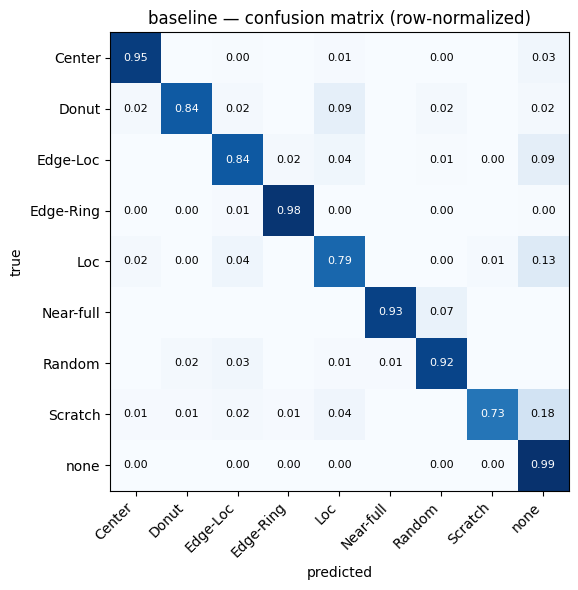

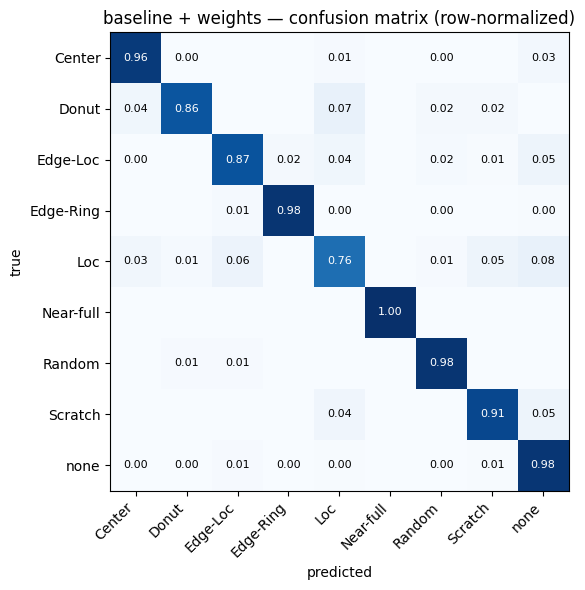

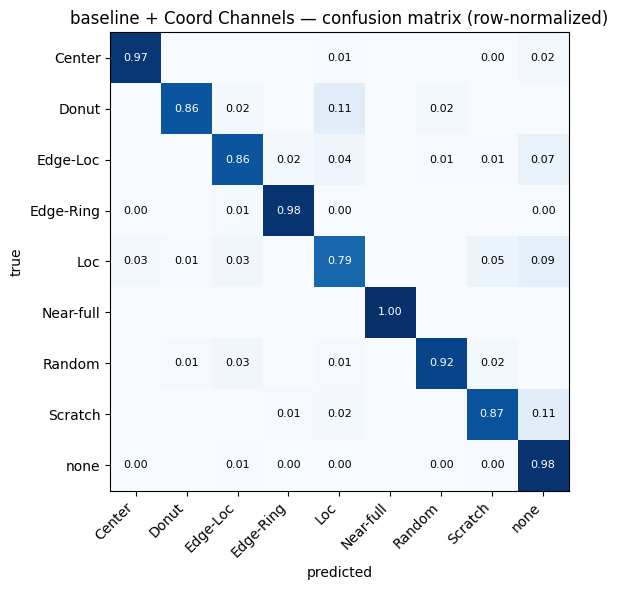

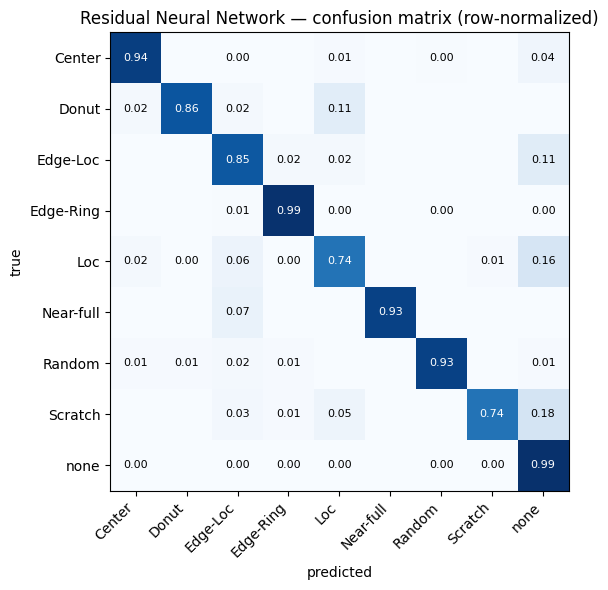

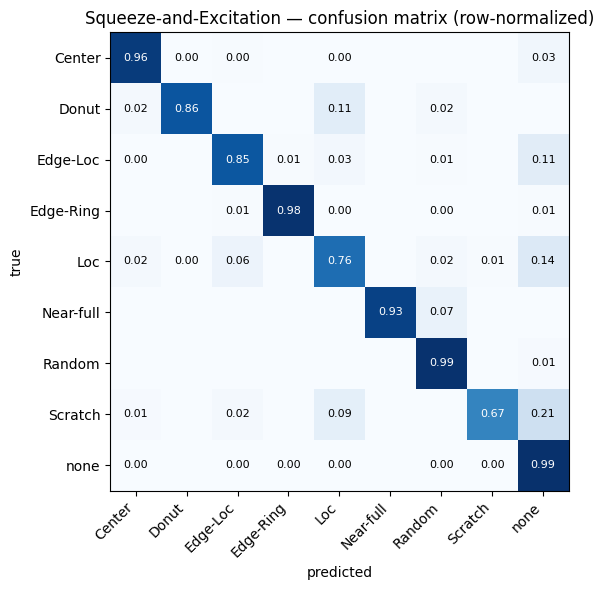

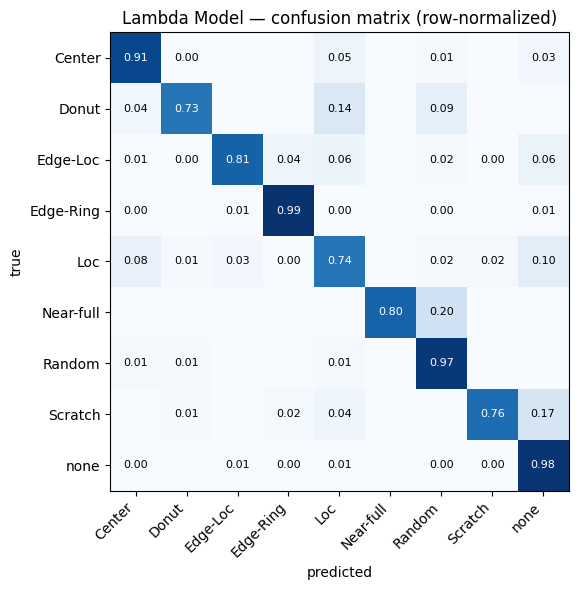

: 

In [ ]:

X_test = np.load("X_test_taku.npy")          # the imbalanced test set
y_test = np.load("y_test_taku.npy")

ClassMapping = ["Center","Donut","Edge-Loc","Edge-Ring","Loc",
                "Near-full","Random","Scratch","none"]

baseline = models.load_model("taku_modelv1.keras")  
baseline_plus_weights = models.load_model("taku_modelv1b.keras")

coord_channels = models.load_model(
    "taku_modelv2a.keras",
    custom_objects={"AddCoordChannels": AddCoordChannels},
    compile=False,
)

resNet = models.load_model("taku_modelv2b.keras")

se_block = models.load_model(
    "taku_modelv2c.keras",
    custom_objects={"SEBlock": SEBlock},
    compile=False,
)

lambda_model = models.load_model("manu_model.keras", safe_mode=False, compile=False)

models_to_eval = {
    "baseline": baseline,
    "baseline + weights": baseline_plus_weights,
    "baseline + Coord Channels": coord_channels,
    "Residual Neural Network": resNet,
    "Squeeze-and-Excitation": se_block,
    "Lambda Model": lambda_model
}
summary, per_class, results = evaluate_models(
    models_to_eval, X_test, y_test, ClassMapping)

for name in results:
    plot_confusion_matrix(results, name, ClassMapping)
    plt.show()
    
per_class["f1"].to_csv("per_class_f1.csv")               # drop into your tracker